[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter7_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 7: Regime-switching models

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- A transparent numpy engine: Hamilton filter, Kim smoother, EM, numerical ML on the expanded state, TVTP, MS-VAR, MS-GARCH, Gibbs sampling with FFBS.
- Hamilton (1989) and Filardo (1994) replicated and compared with statsmodels.
- Testing the number of regimes by bootstrap; forecasting and its evaluation.
- Applications: US business cycle, Romanian GDP and inflation, S&P 500 and BET, EUR/RON.
- Some computations use fewer replications or a shorter sample than the slides, to keep the run short.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_7'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## The numpy engine and the data loaders

- `hamilton_filter`, `kim_smoother`, `ffbs`: filtering, smoothing and sampling of the regimes.
- `em_msr`, `best_em`, `msr_ml`: EM (Hamilton 1990) and numerical ML for MS regressions (MSI, MSIH, MSIAH).
- `msm_fit`: Hamilton's switching-mean AR on the expanded state, constant or time-varying transitions.
- `em_msvar`, `regime_irf`; `msgarch_fit`; `gibbs_ms`.

In [5]:
import math
SEED = 2026
RO_HICP = ('prc_hicp_minr', 'M.I25.TOTAL.RO')
RO_GDP = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
US = {'start': '1947-04-01', 'est_end': '2019-10-01', 'ham_start': '1952-04-01', 'end': '2026-04-01'}
MARKET = {'start': '2000-01-01', 'end': '2026-09-18'}
EVENTS_EURRON = [('2005-07-01', 'RON redenomination'), ('2008-10-01', 'October 2008'), ('2025-05-01', 'May 2025')]
_FILES = {}


def read_ecb(flow, key, start=None):
    """One series from the ECB Data Portal (public SDMX REST API, CSV), e.g. the monthly USD/EUR reference rate:
        read_ecb('EXR', 'M.USD.EUR.SP00.A')
    or the euro-area HICP annual rate of change: read_ecb('ICP', 'M.U2.N.000000.4.ANR')."""
    url = (f'https://data-api.ecb.europa.eu/service/data/{flow}/{key}?format=csvdata'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('ecb', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{flow}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def cached(key, fn):
    if key not in _FILES:
        _FILES[key] = fn()
    return _FILES[key]


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def hamilton_gnp():
    """Hamilton's (1989) data: 100 x change of log real GNP, 1951Q2-1984Q4 (as distributed with statsmodels)."""
    from statsmodels.tsa.regime_switching.tests.test_markov_autoregression import rgnp
    return pd.Series(np.asarray(rgnp, float), index=pd.period_range('1951Q2', periods=len(rgnp), freq='Q').to_timestamp(),
                     name='rgnp')


def filardo_data():
    """Filardo's (1994) data: monthly growth of US industrial production (dlip) and of the composite leading indicator
    (dmdlleading), 1948-1991 (as distributed with statsmodels)."""
    import statsmodels
    p = os.path.join(os.path.dirname(statsmodels.__file__), 'tsa', 'regime_switching', 'tests', 'results', 'mar_filardo.csv')
    d = pd.read_csv(p)[['dlip', 'dmdlleading']]
    d.index = pd.date_range('1948-01-01', periods=len(d), freq='MS')
    return d


def us_gdp():
    """US real GDP growth (100 x change of log GDPC1, % per quarter) and the NBER recession quarters (USRECQ)."""
    def get():
        g = read_fred('GDPC1')
        y = (100 * np.log(g).diff()).dropna().rename('gdp')
        rec = read_fred('USRECQ').reindex(y.index).fillna(0).astype(int)
        return y, rec
    return cached('us_gdp', get)


def us_unemp_q():
    return cached('us_u', lambda: read_fred('UNRATE').resample('QS').mean())


def ro_gdp():
    g = cached('ro_gdp', lambda: read_eurostat(*RO_GDP))
    return (100 * np.log(g).diff()).dropna().rename('ro_gdp')


def ro_inflation():
    """Romanian annual HICP inflation, 100 x log(P_t / P_{t-12}), monthly from January 1997."""
    p = cached('ro_hicp', lambda: read_eurostat(*RO_HICP))
    return (100 * np.log(p).diff(12)).dropna().rename('ro_infl')


def weekly_returns(name, start=MARKET['start'], end=MARKET['end']):
    """Weekly log returns (%), Friday closes (last trading day of each week)."""
    p = load_close(name, start, end).resample('W-FRI').last().dropna()
    return (100 * np.log(p).diff()).dropna().rename(name)


def eurron_daily():
    """EUR/RON: ECB euro reference rate for the leu before July 2005 (old lei rescaled to RON), official BNR reference
    rate from 1 July 2005 (redenomination)."""
    def get():
        ecb = read_ecb('EXR', 'D.RON.EUR.SP00.A').loc[:'2005-06-30']
        bnr = read_reference_rate('EUR', start='2005-07-01')
        return pd.concat([ecb, bnr]).sort_index().rename('eurron')
    return cached('eurron', get)


def shade(ax, ind, color=st.Amber, alpha=0.2):
    """Shade the periods where the 0/1 indicator equals 1 (date index)."""
    ind = ind.astype(int)
    on = False
    idx = ind.index
    for i, v in enumerate(ind.values):
        if v and not on:
            s, on = idx[i], True
        if on and (not v or i == len(ind) - 1):
            ax.axvspan(s, idx[i], color=color, alpha=alpha, lw=0, label='_shade')
            on = False


def patch(color, alpha=0.2):
    from matplotlib.patches import Patch
    return Patch(color=color, alpha=alpha)


def ergodic(P):
    """Ergodic (stationary) probabilities of a transition matrix P[i, j] = Pr(S_t = j | S_{t-1} = i):
    the left eigenvector of P for the eigenvalue 1, i.e. the solution of pi' P = pi', sum(pi) = 1."""
    M = P.shape[0]
    A = np.vstack([P.T - np.eye(M), np.ones(M)])
    b = np.r_[np.zeros(M), 1.0]
    return np.linalg.lstsq(A, b, rcond=None)[0]


def durations(P):
    """Expected duration of each regime, 1 / (1 - p_ii)."""
    return 1.0 / (1.0 - np.diag(P))


def simulate_chain(P, T, rng, s0=None):
    M = P.shape[0]
    s = np.empty(T, dtype=int)
    s[0] = rng.choice(M, p=ergodic(P)) if s0 is None else s0
    u = rng.random(T)
    cum = np.cumsum(P, axis=1)
    for t in range(1, T):
        s[t] = min(int(np.searchsorted(cum[s[t - 1]], u[t])), M - 1)
    return s


def hamilton_filter(logf, P, xi1=None):
    """Hamilton filter.
    logf : T x M array, log f(y_t | S_t = j, Y_{t-1}) for each regime j;
    P    : M x M transition matrix (rows sum to 1) or T x M x M array, P[t] the transition from t-1 to t;
    xi1  : Pr(S_1 = j | Y_0), the ergodic probabilities by default.
    Returns pred (xi_{t|t-1}), filt (xi_{t|t}), the log-likelihood and its contributions log f(y_t | Y_{t-1})."""
    T, M = logf.shape
    tv = P.ndim == 3
    pred = np.empty((T, M))
    filt = np.empty((T, M))
    llt = np.empty(T)
    xi = ergodic(P[0] if tv else P) if xi1 is None else np.asarray(xi1, float)
    for t in range(T):
        if t > 0:
            xi = filt[t - 1] @ (P[t] if tv else P)          # prediction: xi_{t|t-1} = P' xi_{t-1|t-1}
        pred[t] = xi
        m = logf[t].max()
        w = xi * np.exp(logf[t] - m)                         # xi_{t|t-1} * f_j(y_t), scaled by exp(-m)
        s = w.sum()
        llt[t] = m + np.log(s)                               # log f(y_t | Y_{t-1}) = log sum_j xi_j f_j
        filt[t] = w / s                                      # Bayes update
    return dict(pred=pred, filt=filt, loglik=float(llt.sum()), llt=llt)


def kim_smoother(filt, pred, P):
    """Kim (1994) smoother: smoothed probabilities xi_{t|T} and joint smoothed probabilities
    Pr(S_{t-1} = i, S_t = j | Y_T) (stored in joint[t], t >= 1), from
    Pr(S_t = i, S_{t+1} = j | Y_T) = xi_{t|t}(i) p_ij xi_{t+1|T}(j) / xi_{t+1|t}(j)."""
    T, M = filt.shape
    tv = P.ndim == 3
    sm = np.empty((T, M))
    joint = np.zeros((T, M, M))
    sm[-1] = filt[-1]
    for t in range(T - 2, -1, -1):
        Pn = P[t + 1] if tv else P
        ratio = np.divide(sm[t + 1], pred[t + 1], out=np.zeros(M), where=pred[t + 1] > 0)
        J = filt[t][:, None] * Pn * ratio[None, :]
        sm[t] = J.sum(axis=1)
        joint[t + 1] = J
    return sm, joint


def ffbs(filt, P, rng):
    """Forward filtering, backward sampling (Chib 1996): one draw of the whole regime path S_1..S_T from
    p(S | Y, theta) = p(S_T | Y) prod_t p(S_t | S_{t+1}, Y_t), with p(S_t = i | S_{t+1} = j, Y_t) prop. to xi_{t|t}(i) p_ij."""
    T, M = filt.shape
    tv = P.ndim == 3
    s = np.empty(T, dtype=int)
    u = rng.random(T)
    s[-1] = min(int(np.searchsorted(np.cumsum(filt[-1]), u[-1])), M - 1)
    for t in range(T - 2, -1, -1):
        Pn = P[t + 1] if tv else P
        w = filt[t] * Pn[:, s[t + 1]]
        s[t] = min(int(np.searchsorted(np.cumsum(w / w.sum()), u[t])), M - 1)
    return s


def lag_design(y, p, const=True):
    """Response y_t and regressors (1, y_{t-1}, ..., y_{t-p}) for t = p, ..., T-1."""
    y = np.asarray(y, float)
    X = [y[p - k:len(y) - k] for k in range(1, p + 1)]
    if const:
        X = [np.ones(len(y) - p)] + X
    return y[p:], (np.column_stack(X) if X else np.empty((len(y) - p, 0)))


def msr_logf(y, X, beta, sig2):
    """log N(y_t; x_t' beta_j, sigma2_j) for each regime: beta is K x k, sig2 has K entries."""
    mu = X @ beta.T                                                  # T x K
    return -0.5 * (np.log(2 * np.pi * sig2)[None, :] + (y[:, None] - mu) ** 2 / sig2[None, :])


def _wls_shared(y, X, W, sig2, switch):
    """M-step for coefficients when some are switching (switch[k] True) and others common to all regimes:
    weighted least squares on the stacked design, weights W[t, j] / sigma2_j."""
    T, k = X.shape
    K = W.shape[1]
    sw = np.where(switch)[0]
    ns = np.where(~np.asarray(switch))[0]
    npar = len(ns) + K * len(sw)
    A = np.zeros((npar, npar))
    b = np.zeros(npar)
    for j in range(K):
        D = np.zeros((T, npar))
        D[:, :len(ns)] = X[:, ns]
        D[:, len(ns) + j * len(sw):len(ns) + (j + 1) * len(sw)] = X[:, sw]
        w = W[:, j] / sig2[j]
        A += D.T @ (D * w[:, None])
        b += D.T @ (w * y)
    th = np.linalg.solve(A, b)
    beta = np.zeros((K, k))
    for j in range(K):
        beta[j, ns] = th[:len(ns)]
        beta[j, sw] = th[len(ns) + j * len(sw):len(ns) + (j + 1) * len(sw)]
    return beta


def em_msr(y, X, K, switch=None, switch_var=True, P0=None, beta0=None, sig20=None, maxit=1000, tol=1e-8,
           P_mask=None, rng=None, var_floor=1e-6, xi1_fixed=None):
    """EM algorithm of Hamilton (1990) for y_t = x_t' beta_{S_t} + e_t, e_t ~ N(0, sigma2_{S_t}).
    switch     : boolean mask of the switching coefficients (default: all switch);
    switch_var : regime-specific variances (True) or a common variance;
    P_mask     : optional 0/1 mask of allowed transitions (e.g. an upper-triangular change-point model, Chib 1998);
    xi1_fixed  : a fixed distribution of S_1 (e.g. (1, 0, ..., 0) for a change-point model), otherwise estimated.
    E-step: Hamilton filter + Kim smoother. M-step: p_ij = sum_t Pr(S_{t-1}=i, S_t=j|Y_T) / sum_t Pr(S_{t-1}=i|Y_T);
    weighted least squares for beta_j with weights xi_{t|T}(j); sigma2_j = weighted mean of squared residuals.
    The distribution of S_1 is a free parameter, estimated by xi_{1|T} (Hamilton 1990): then each EM step cannot lower
    the likelihood. The final likelihood is reported both with this estimate and with the ergodic distribution."""
    y = np.asarray(y, float)
    X = np.asarray(X, float)
    T, k = X.shape
    switch = np.ones(k, bool) if switch is None else np.asarray(switch, bool)
    rng = rng or np.random.default_rng(0)
    if beta0 is None:
        b_ols = np.linalg.lstsq(X, y, rcond=None)[0]
        s_ols = np.std(y - X @ b_ols)
        beta = np.tile(b_ols, (K, 1))
        if switch_var and rng.random() < 0.5:        # a start that separates the regimes by their variances
            sig2 = s_ols ** 2 * np.geomspace(0.2, 2.5, K) * rng.uniform(0.7, 1.3, K)
            if switch.any():
                beta[:, np.where(switch)[0][0]] += 0.1 * s_ols * rng.normal(size=K)
        else:                                         # a start that separates the regimes by their means
            if switch.any():
                beta[:, np.where(switch)[0][0]] += np.linspace(-1, 1, K) * s_ols * (0.5 + rng.random(K))
            sig2 = np.full(K, s_ols ** 2) * (np.linspace(0.5, 1.5, K) if switch_var else 1.0)
    else:
        beta, sig2 = np.array(beta0, float), np.array(sig20, float)
    if P0 is None:
        d = rng.uniform(0.6, 0.97, K) if K > 1 else np.ones(1)
        P = np.where(np.eye(K, dtype=bool), d[:, None], ((1 - d) / max(K - 1, 1))[:, None])
    else:
        P = np.array(P0, float)
    if P_mask is not None:
        P = P * P_mask
        P = P / P.sum(1, keepdims=True)
    path = []
    xi1 = ergodic(P) if xi1_fixed is None else np.asarray(xi1_fixed, float)
    for it in range(maxit):
        f = hamilton_filter(msr_logf(y, X, beta, sig2), P, xi1)
        path.append(f['loglik'])
        sm, joint = kim_smoother(f['filt'], f['pred'], P)
        if xi1_fixed is None:
            xi1 = np.clip(sm[0], 1e-10, None) / np.clip(sm[0], 1e-10, None).sum()   # M-step: Pr(S_1 = j)
        # M-step: transition probabilities
        num = joint[1:].sum(axis=0)
        den = sm[:-1].sum(axis=0)
        P = num / den[:, None]
        if P_mask is not None:
            P = P * P_mask
        P = np.clip(P, 1e-12, None)
        P = P / P.sum(1, keepdims=True)
        # M-step: coefficients and variances
        if switch.all():
            beta = np.vstack([np.linalg.solve(X.T @ (X * sm[:, j:j + 1]), X.T @ (sm[:, j] * y)) for j in range(K)])
        else:
            beta = _wls_shared(y, X, sm, sig2, switch)
        res2 = (y[:, None] - X @ beta.T) ** 2
        if switch_var:
            sig2 = np.maximum((sm * res2).sum(0) / sm.sum(0), var_floor)
        else:
            sig2 = np.full(K, max((sm * res2).sum() / T, var_floor))
        if it > 2 and abs(path[-1] - path[-2]) < tol * (1 + abs(path[-1])):
            break
    f_free = hamilton_filter(msr_logf(y, X, beta, sig2), P, xi1)
    f = f_free if xi1_fixed is not None else hamilton_filter(msr_logf(y, X, beta, sig2), P)
    sm, joint = kim_smoother(f['filt'], f['pred'], P)
    npar = K * (K - 1) + int(switch.sum()) * K + int((~switch).sum()) + (K if switch_var else 1)
    if P_mask is not None:
        npar -= int((P_mask == 0).sum())
    return dict(beta=beta, sig2=sig2, P=P, loglik=f['loglik'], loglik_free=f_free['loglik'], filt=f['filt'],
                pred=f['pred'], smooth=sm, path=np.array(path + [f_free['loglik']]), iters=it + 1, npar=npar, T=T, K=K,
                switch=switch, switch_var=switch_var)


def order_regimes(r, key='mean', col=0):
    """Relabel the regimes of an em_msr result in increasing order of the intercept (key='mean') or of the variance
    (key='var'): one identification restriction against label switching."""
    o = np.argsort(r['beta'][:, col] if key == 'mean' else r['sig2'])
    out = dict(r)
    out['beta'], out['sig2'] = r['beta'][o], r['sig2'][o]
    out['order'] = o
    out['P'] = r['P'][np.ix_(o, o)]
    for k in ('filt', 'pred', 'smooth'):
        out[k] = r[k][:, o]
    return out


def best_em(y, X, K, starts=10, seed=0, order='mean', polish=False, **kw):
    """EM from several random starting values; the best log-likelihood wins (EM finds local maxima);
    polish=True finishes with numerical ML from the best EM solution (msr_ml)."""
    rng = np.random.default_rng(seed)
    best, lls = None, []
    for s in range(starts):
        try:
            r = em_msr(y, X, K, rng=rng, **kw)
        except np.linalg.LinAlgError:
            continue
        lls.append(r['loglik'])
        if best is None or r['loglik'] > best['loglik']:
            best = r
    best = order_regimes(best, order) if order else best
    if polish:
        best = msr_ml(y, X, best)
    best['start_ll'] = np.array(lls)
    return best


def info_criteria(loglik, npar, T):
    return dict(AIC=-2 * loglik + 2 * npar, BIC=-2 * loglik + npar * np.log(T), HQ=-2 * loglik + 2 * npar * np.log(np.log(T)))


def linear_ar(y, X):
    """Gaussian linear regression (K = 1): ML estimates and log-likelihood."""
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    s2 = e @ e / len(y)
    return dict(beta=b, sig2=s2, loglik=float(-0.5 * len(y) * (np.log(2 * np.pi * s2) + 1)), npar=X.shape[1] + 1)


def msr_pack(r):
    """Unconstrained parameters of an MS regression: common coefficients, switching coefficients by regime,
    log variances, and for each row i of P the logs of p_ij / p_ii (j != i)."""
    K, sw = r['K'], r['switch']
    th = list(r['beta'][0, ~sw]) + list(r['beta'][:, sw].ravel())
    th += list(np.log(r['sig2'] if r['switch_var'] else r['sig2'][:1]))
    P = r['P']
    for i in range(K):
        th += [np.log(P[i, j] / P[i, i]) for j in range(K) if j != i]
    return np.array(th)


def msr_unpack(th, K, k, sw, switch_var):
    ns, nsw = int((~sw).sum()), int(sw.sum())
    beta = np.zeros((K, k))
    beta[:, ~sw] = th[:ns]
    beta[:, sw] = th[ns:ns + K * nsw].reshape(K, nsw)
    pos = ns + K * nsw
    nv = K if switch_var else 1
    sig2 = np.exp(th[pos:pos + nv]) * np.ones(K)
    pos += nv
    P = np.zeros((K, K))
    for i in range(K):
        a = np.zeros(K)
        a[[j for j in range(K) if j != i]] = th[pos:pos + K - 1]
        pos += K - 1
        P[i] = np.exp(a - a.max()) / np.exp(a - a.max()).sum()
    return beta, sig2, P


def msr_ml(y, X, r):
    """Numerical ML with the ergodic initial distribution (BFGS on unconstrained parameters), started from an EM
    solution r; standard errors of the natural parameters (coefficients, variances, p_ii) by the delta method
    from the numerical Hessian of the log-likelihood."""
    K, k, sw, sv = r['K'], X.shape[1], r['switch'], r['switch_var']

    def nll(th):
        beta, sig2, P = msr_unpack(th, K, k, sw, sv)
        return -hamilton_filter(msr_logf(y, X, beta, sig2), P)['loglik']
    o = optimize.minimize(nll, msr_pack(r), method='BFGS', options=dict(gtol=1e-7, maxiter=5000))

    def nat(th):
        beta, sig2, P = msr_unpack(th, K, k, sw, sv)
        return np.r_[beta[0, ~sw], beta[:, sw].ravel(), sig2 if sv else sig2[:1], np.diag(P)]
    try:
        V = np.linalg.inv(num_hessian(nll, o.x))
        J = num_jacobian(nat, o.x)
        se = np.sqrt(np.clip(np.diag(J @ V @ J.T), 0, None))
    except np.linalg.LinAlgError:
        se = np.full(len(nat(o.x)), np.nan)
    beta, sig2, P = msr_unpack(o.x, K, k, sw, sv)
    f = hamilton_filter(msr_logf(y, X, beta, sig2), P)
    sm, _ = kim_smoother(f['filt'], f['pred'], P)
    out = dict(r)
    out.update(beta=beta, sig2=sig2, P=P, loglik=f['loglik'], filt=f['filt'], pred=f['pred'], smooth=sm, se=se,
               theta=nat(o.x), nfev=o.nfev)
    return out


def num_hessian(f, x, h=1e-4):
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            ei, ej = np.zeros(n), np.zeros(n)
            ei[i], ej[j] = h, h
            H[i, j] = H[j, i] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h * h)
    return H


def num_jacobian(f, x, h=1e-6):
    f0 = np.asarray(f(x))
    J = np.zeros((len(f0), len(x)))
    for i in range(len(x)):
        e = np.zeros(len(x))
        e[i] = h
        J[:, i] = (np.asarray(f(x + e)) - np.asarray(f(x - e))) / (2 * h)
    return J


def expanded_states(K, p):
    """All tuples (S_t, S_{t-1}, ..., S_{t-p}) and the transition map between them."""
    import itertools
    tup = np.array(list(itertools.product(range(K), repeat=p + 1)))       # column 0 = S_t
    M = len(tup)
    index = {tuple(r): i for i, r in enumerate(tup)}
    frm, to = [], []
    for i, r in enumerate(tup):
        for j0 in range(K):
            frm.append(i)
            to.append(index[(j0,) + tuple(r[:p])])
    return tup, np.array(frm), np.array(to)


def msm_logf(y, p, mu, phi, sig2, tup):
    """log f(y_t | S_t..S_{t-p}, Y_{t-1}) for y_t - mu_{S_t} = sum_k phi_k (y_{t-k} - mu_{S_{t-k}}) + e_t."""
    T = len(y) - p
    mus = mu[tup]                                   # M x (p+1)
    e = y[p:, None] - mus[None, :, 0]
    for k in range(1, p + 1):
        e = e - phi[k - 1] * (y[p - k:len(y) - k, None] - mus[None, :, k])
    return -0.5 * (np.log(2 * np.pi * sig2) + e ** 2 / sig2)


def expand_P(P2, K, p, tup, frm, to):
    """Transition matrix of the expanded state from the K x K regime matrix (constant or T x K x K)."""
    M = len(tup)
    if P2.ndim == 2:
        Pe = np.zeros((M, M))
        Pe[frm, to] = P2[tup[frm, 0], tup[to, 0]]
        return Pe
    Pe = np.zeros((P2.shape[0], M, M))
    Pe[:, frm, to] = P2[:, tup[frm, 0], tup[to, 0]]
    return Pe


def msm_unpack(th, K, p, Z=None):
    """theta = (mu_1..mu_K, phi_1..phi_p, log sigma2, transition parameters). Two regimes: constant (logit p11,
    logit p22) or TVTP: Pr(S_t = i | S_{t-1} = i) = logistic(z_{t-1}' gamma_i) (Diebold, Lee, Weinbach 1994)."""
    mu = th[:K]
    phi = th[K:K + p]
    sig2 = np.exp(th[K + p])
    g = th[K + p + 1:]
    if Z is None:
        q = 1 / (1 + np.exp(-g))
        P2 = np.array([[q[0], 1 - q[0]], [1 - q[1], q[1]]])
    else:
        nz = Z.shape[1]
        q1 = 1 / (1 + np.exp(-(Z @ g[:nz])))
        q2 = 1 / (1 + np.exp(-(Z @ g[nz:])))
        P2 = np.zeros((len(Z), 2, 2))
        P2[:, 0, 0], P2[:, 0, 1], P2[:, 1, 0], P2[:, 1, 1] = q1, 1 - q1, 1 - q2, q2
    return mu, phi, sig2, P2


def expanded_init(P2, K, p, tup):
    """Distribution of the first expanded state (S_p, ..., S_0): S_0 from the ergodic distribution of the first
    transition matrix, then p steps of the chain (with time-varying matrices, those of periods 1..p)."""
    pi = ergodic(P2[0] if P2.ndim == 3 else P2)
    J = {(s,): pi[s] for s in range(K)}
    for r in range(1, p + 1):
        Pr = P2[r] if P2.ndim == 3 else P2
        J = {(j,) + key: v * Pr[key[0], j] for key, v in J.items() for j in range(K)}
    return np.array([J[tuple(t)] for t in tup])


def msm_filter(th, y, K, p, Z=None, tup=None, frm=None, to=None):
    """Hamilton filter of the switching-mean AR(p). Z (optional): T x m transition covariates for the FULL sample y,
    row t holding the variables that drive Pr(S_t | S_{t-1}) (e.g. z_{t-1})."""
    if tup is None:
        tup, frm, to = expanded_states(K, p)
    mu, phi, sig2, P2 = msm_unpack(th, K, p, Z)
    Pe = expand_P(P2[p:] if Z is not None else P2, K, p, tup, frm, to)
    logf = msm_logf(y, p, mu, phi, sig2, tup)
    f = hamilton_filter(logf, Pe, expanded_init(P2, K, p, tup))
    return f, Pe, tup


def msm_negll(th, y, K, p, Z, tup, frm, to):
    try:
        return -msm_filter(th, y, K, p, Z, tup, frm, to)[0]['loglik']
    except (FloatingPointError, np.linalg.LinAlgError, ValueError):
        return 1e10


def msm_fit(y, p, K=2, Z=None, starts=None, seed=0, nrand=10):
    """Numerical ML of Hamilton's switching-mean AR(p) (BFGS from several starting values).
    Z: T x m matrix of transition covariates for the full sample y (row t holds z_{t-1}), or None."""
    y = np.asarray(y, float)
    tup, frm, to = expanded_states(K, p)
    rng = np.random.default_rng(seed)
    nz = 1 if Z is None else Z.shape[1]
    s = np.std(y)
    base = []
    for _ in range(nrand):
        mu0 = np.sort(np.mean(y) + s * rng.normal(0, 1, K))
        g0 = (rng.uniform(1, 3, 2) if Z is None else np.r_[rng.uniform(1, 3), np.zeros(nz - 1), rng.uniform(1, 3), np.zeros(nz - 1)])
        base.append(np.r_[mu0, rng.normal(0, 0.1, p), np.log(s ** 2 * rng.uniform(0.3, 1)), g0])
    best = None
    for th0 in (starts or []) + base:
        o = optimize.minimize(msm_negll, np.asarray(th0, float), args=(y, K, p, Z, tup, frm, to), method='BFGS',
                              options=dict(gtol=1e-6, maxiter=3000))
        if best is None or o.fun < best.fun:
            best = o
    f, Pe, _ = msm_filter(best.x, y, K, p, Z, tup, frm, to)
    sm, _ = kim_smoother(f['filt'], f['pred'], Pe)
    mu, phi, sig2, P2 = msm_unpack(best.x, K, p, Z)
    # regime probabilities of S_t: sum over the tuples with S_t = j
    agg = lambda a: np.column_stack([a[:, tup[:, 0] == j].sum(1) for j in range(K)])
    H = num_hessian(lambda t: msm_negll(t, y, K, p, Z, tup, frm, to), best.x)
    try:
        se_th = np.sqrt(np.diag(np.linalg.inv(H)))
    except np.linalg.LinAlgError:
        se_th = np.full(len(best.x), np.nan)
    return dict(theta=best.x, se_theta=se_th, mu=mu, phi=phi, sig2=sig2, P=P2, loglik=-best.fun,
                filt=agg(f['filt']), smooth=agg(sm), pred=agg(f['pred']), npar=len(best.x), T=len(y) - p)


def var_design(Y, p):
    Y = np.asarray(Y, float)
    X = np.column_stack([np.ones(len(Y) - p)] + [Y[p - k:len(Y) - k] for k in range(1, p + 1)])
    return Y[p:], X


def msvar_logf(Y, X, B, S):
    T, n = Y.shape
    K = len(B)
    out = np.empty((T, K))
    for j in range(K):
        E = Y - X @ B[j]
        L = np.linalg.cholesky(S[j])
        Z = np.linalg.solve(L, E.T)
        out[:, j] = -0.5 * (n * np.log(2 * np.pi) + 2 * np.log(np.diag(L)).sum() + (Z ** 2).sum(0))
    return out


def em_msvar(Y, p, K=2, maxit=2000, tol=1e-9, seed=0, starts=10):
    """EM for the MSIAH(K)-VAR(p): regime-dependent intercepts, lag matrices and covariances (Krolzig 1997, ch. 6);
    the M-step is a weighted multivariate least-squares regression in each regime."""
    Yt, X = var_design(Y, p)
    T, n = Yt.shape
    rng = np.random.default_rng(seed)
    best = None
    B_ols = np.linalg.lstsq(X, Yt, rcond=None)[0]
    S_ols = np.cov((Yt - X @ B_ols).T)
    for s in range(starts):
        W = rng.dirichlet(np.ones(K) * 0.5, size=T)
        W = np.array([np.convolve(W[:, j], np.ones(5) / 5, 'same') for j in range(K)]).T + 1e-3
        W /= W.sum(1, keepdims=True)
        P = np.full((K, K), 0.05 / max(K - 1, 1)) + np.eye(K) * (0.95 - 0.05 / max(K - 1, 1))
        B = [np.linalg.solve(X.T @ (X * W[:, [j]]), X.T @ (Yt * W[:, [j]])) for j in range(K)]
        S = [S_ols.copy() for _ in range(K)]
        path = []
        try:
            for it in range(maxit):
                f = hamilton_filter(msvar_logf(Yt, X, B, S), P)
                path.append(f['loglik'])
                sm, joint = kim_smoother(f['filt'], f['pred'], P)
                P = joint[1:].sum(0) / sm[:-1].sum(0)[:, None]
                P = np.clip(P, 1e-12, None)
                P /= P.sum(1, keepdims=True)
                for j in range(K):
                    w = sm[:, [j]]
                    B[j] = np.linalg.solve(X.T @ (X * w), X.T @ (Yt * w))
                    E = Yt - X @ B[j]
                    S[j] = (E * w).T @ E / w.sum() + 1e-8 * np.eye(n)
                if it > 2 and abs(path[-1] - path[-2]) < tol * (1 + abs(path[-1])):
                    break
        except np.linalg.LinAlgError:
            continue
        f = hamilton_filter(msvar_logf(Yt, X, B, S), P)
        if best is None or f['loglik'] > best['loglik']:
            sm, _ = kim_smoother(f['filt'], f['pred'], P)
            best = dict(B=[b.copy() for b in B], S=[x.copy() for x in S], P=P.copy(), loglik=f['loglik'], smooth=sm,
                        filt=f['filt'], iters=it + 1, T=T, n=n, p=p, K=K, npar=K * (n * (1 + n * p) + n * (n + 1) // 2) + K * (K - 1))
    return best


def regime_irf(B, S, n, p, H, shock=0):
    """Regime-dependent impulse responses (Ehrmann, Ellison and Valla 2003): the responses of the VAR of one regime
    to a one-standard-deviation orthogonalised (Cholesky) shock, assuming the regime stays in place for H periods."""
    A = [B[1 + n * (k - 1):1 + n * k].T for k in range(1, p + 1)]
    L = np.linalg.cholesky(S)
    Psi = [np.eye(n)]
    for h in range(1, H + 1):
        Psi.append(sum(A[k - 1] @ Psi[h - k] for k in range(1, min(h, p) + 1)))
    return np.array([Ps @ L[:, shock] for Ps in Psi])          # (H + 1) x n


def msgarch_unpack(th, K):
    mu = th[0]
    om = np.exp(th[1:1 + K])
    a = np.exp(th[1 + K:1 + 2 * K])
    b = np.exp(th[1 + 2 * K:1 + 3 * K])
    if K == 1:
        return mu, om, a, b, np.ones((1, 1))
    q = 1 / (1 + np.exp(-th[1 + 3 * K:1 + 3 * K + 2]))
    return mu, om, a, b, np.array([[q[0], 1 - q[0]], [1 - q[1], q[1]]])


def msgarch_filter(th, r, K=2, kind='hmp'):
    """Log-likelihood and filtered quantities of a K-regime GARCH(1,1) with Normal innovations and a common mean.
    kind='hmp': Haas, Mittnik and Paolella (2004), h_{j,t} = w_j + a_j e_{t-1}^2 + b_j h_{j,t-1} for every regime in
                parallel, so h_{j,t} does not depend on the regime path (no path dependence);
    kind='gray': Gray (1996), h_{j,t} = w_j + a_j e_{t-1}^2 + b_j h_{t-1}, with h_{t-1} the variance of the mixture
                 given Y_{t-2} (the regime history collapsed into one number).
    The recursion runs on plain Python floats (math module), which is fast for a scalar loop."""
    import math
    mu, om, a, b, P = msgarch_unpack(th, K)
    e = (np.asarray(r, float) - mu).tolist()
    om, a, b, Pl = om.tolist(), a.tolist(), b.tolist(), P.tolist()
    T = len(e)
    v0 = float(np.var(r))
    h = [v0] * K
    xi = list(ergodic(P)) if K > 1 else [1.0]
    ll = 0.0
    filt, pred, hpred = [], [], []
    hmix_prev = v0
    c = 0.5 * math.log(2 * math.pi)
    for t in range(T):
        if t > 0:
            e2 = e[t - 1] * e[t - 1]
            if kind == 'hmp':
                h = [om[j] + a[j] * e2 + b[j] * h[j] for j in range(K)]
            else:
                h = [om[j] + a[j] * e2 + b[j] * hmix_prev for j in range(K)]
            xi = [sum(xi[i] * Pl[i][j] for i in range(K)) for j in range(K)]
        hmix_prev = sum(xi[j] * h[j] for j in range(K))
        et2 = e[t] * e[t]
        dens = [xi[j] * math.exp(-c - 0.5 * math.log(h[j]) - 0.5 * et2 / h[j]) for j in range(K)]
        s = sum(dens)
        if not s > 0:
            return -1e10, None
        ll += math.log(s)
        pred.append(xi)
        hpred.append(h)
        xi = [d / s for d in dens]
        filt.append(xi)
    pred, hpred = np.array(pred), np.array(hpred)
    return ll, dict(filt=np.array(filt), pred=pred, h=hpred, hmix=(pred * hpred).sum(1))


def msgarch_fit(r, K=2, kind='hmp', starts=None):
    """Numerical ML (BFGS on log-parameters) of the (MS-)GARCH(1,1); K = 1 gives the ordinary GARCH(1,1)."""
    v = np.var(r)

    def nll(th):
        mu, om, a, b, P = msgarch_unpack(th, K)
        if np.any(a + b >= 0.9999):
            return 1e10
        ll, _ = msgarch_filter(th, r, K, kind)
        return -ll
    if starts is None:
        if K == 1:
            starts = [np.r_[np.mean(r), np.log(0.05 * v), np.log(0.08), np.log(0.9)]]
        else:                                   # starting values around the single-regime GARCH(1,1)
            g = msgarch_fit(r, 1)
            w, al, be = g['omega'][0], g['alpha'][0], g['beta'][0]
            starts = [np.r_[g['mu'], np.log([0.5 * w, 2.0 * w]), np.log([0.7 * al, 1.3 * al]), np.log([be, 0.97 * be]), 3.5, 2.5],
                      np.r_[g['mu'], np.log([0.3 * w, 3.0 * w]), np.log([0.5 * al, 1.5 * al]), np.log([min(be * 1.02, 0.97 - 0.5 * al), 0.9 * be]), 4.0, 3.0],
                      np.r_[g['mu'], np.log([0.02 * v, 0.2 * v]), np.log([0.05, 0.12]), np.log([0.92, 0.8]), 3.5, 2.5],
                      np.r_[g['mu'], np.log([0.01 * v, 0.05 * v]), np.log([0.03, 0.08]), np.log([0.95, 0.9]), 4.0, 3.0]]
    best = None
    for s0 in starts:
        o = optimize.minimize(nll, s0, method='BFGS', options=dict(gtol=1e-4, maxiter=400))
        if best is None or o.fun < best.fun:
            best = o
    mu, om, a, b, P = msgarch_unpack(best.x, K)
    ll, out = msgarch_filter(best.x, r, K, kind)
    return dict(theta=best.x, mu=mu, omega=om, alpha=a, beta=b, P=P, loglik=ll, npar=len(best.x), **out)


def gibbs_ms(y, K=2, n_iter=6000, burn=1000, seed=0, permute=False, prior=None, constrain='mean'):
    """Gibbs sampler for y_t = mu_{S_t} + sigma_{S_t} e_t (Albert and Chib 1993; Chib 1996):
      1. S | mu, sigma2, P, y  by forward filtering-backward sampling (the whole path in one block);
      2. P | S   rows ~ Dirichlet(a_ij + n_ij), n_ij = number of transitions i -> j;
      3. mu_j | sigma2_j, S, y ~ Normal (conjugate), sigma2_j | mu_j, S, y ~ inverse gamma;
      4. permute=True: random permutation of the labels at each sweep (Fruhwirth-Schnatter 2001), which visits all
         K! symmetric modes; the labels are then identified afterwards by the constraint mu_1 < ... < mu_K.
    Returns the draws (after burn-in) and the posterior mean of the regime probabilities."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y, float)
    T = len(y)
    pr = dict(m0=np.mean(y), v0=100 * np.var(y), a0=2.0, d0=np.var(y), a_stay=8.0, a_move=2.0)
    pr.update(prior or {})
    q = np.quantile(y, np.linspace(0.2, 0.8, K))
    mu, sig2 = q.copy(), np.full(K, np.var(y))
    P = np.full((K, K), 0.1 / max(K - 1, 1)) + np.eye(K) * (0.9 - 0.1 / max(K - 1, 1))
    A = np.full((K, K), pr['a_move']) + np.eye(K) * (pr['a_stay'] - pr['a_move'])
    draws = dict(mu=[], sig2=[], P=[])
    prob = np.zeros((T, K))
    kept = 0
    for it in range(n_iter):
        logf = -0.5 * (np.log(2 * np.pi * sig2)[None, :] + (y[:, None] - mu[None, :]) ** 2 / sig2[None, :])
        f = hamilton_filter(logf, P)
        s = ffbs(f['filt'], P, rng)
        n = np.zeros((K, K))
        np.add.at(n, (s[:-1], s[1:]), 1)
        P = np.vstack([rng.dirichlet(A[i] + n[i]) for i in range(K)])
        for j in range(K):
            yj = y[s == j]
            vj = 1 / (1 / pr['v0'] + len(yj) / sig2[j])
            mu[j] = rng.normal(vj * (pr['m0'] / pr['v0'] + yj.sum() / sig2[j]), np.sqrt(vj))
            sig2[j] = 1 / rng.gamma(pr['a0'] + len(yj) / 2, 1 / (pr['d0'] + ((yj - mu[j]) ** 2).sum() / 2))
        if permute:
            o = rng.permutation(K)
            mu, sig2, P, s = mu[o], sig2[o], P[np.ix_(o, o)], np.argsort(o)[s]
        if it >= burn:
            draws['mu'].append(mu.copy())
            draws['sig2'].append(sig2.copy())
            draws['P'].append(P.copy())
            onehot = np.zeros((T, K))
            onehot[np.arange(T), s] = 1
            if constrain == 'mean':
                o = np.argsort(mu)
                onehot = onehot[:, o]
            prob += onehot
            kept += 1
    out = {k: np.array(v) for k, v in draws.items()}
    out['prob'] = prob / kept
    if constrain == 'mean':
        o = np.argsort(out['mu'], axis=1)
        idx = np.arange(len(o))[:, None]
        out['mu_id'] = out['mu'][idx, o]
        out['sig2_id'] = out['sig2'][idx, o]
        out['P_id'] = np.array([Pd[np.ix_(oo, oo)] for Pd, oo in zip(out['P'], o)])
    return out


def msr_forecast(r, X_next, h=1):
    """h-step regime probabilities xi_{T+h|T} = (P')^h xi_{T|T} and the one-step mixture density moments
    for the next observation, given its regressors X_next (1 x k)."""
    xi = r['filt'][-1] @ np.linalg.matrix_power(r['P'], h)
    m = X_next @ r['beta'].T
    mean = float(xi @ m.ravel())
    var = float(xi @ (r['sig2'] + (m.ravel() - mean) ** 2))
    return xi, mean, var


def mixture_logscore(y, xi, means, sig2):
    return float(np.log(np.sum(xi * stats.norm.pdf(y, means, np.sqrt(sig2)))))


def mixture_pit(y, xi, means, sig2):
    return float(np.sum(xi * stats.norm.cdf(y, means, np.sqrt(sig2))))


def qps(prob, event):
    """Quadratic probability score (Brier 1950; Diebold and Rudebusch 1989): 2/T sum (p_t - d_t)^2, between 0 and 2."""
    prob, event = np.asarray(prob, float), np.asarray(event, float)
    return float(2 * np.mean((prob - event) ** 2))


def concordance(a, b):
    """Concordance index of Harding and Pagan (2002): share of periods in which two 0/1 phase indicators agree."""
    a, b = np.asarray(a, int), np.asarray(b, int)
    return float(np.mean(a * b + (1 - a) * (1 - b)))


def gph(x, power=0.5):
    """Geweke and Porter-Hudak log-periodogram estimate of the memory parameter d, m = T^power frequencies."""
    x = np.asarray(x, float) - np.mean(x)
    T = len(x)
    m = int(T ** power)
    lam = 2 * np.pi * np.arange(1, m + 1) / T
    I = np.abs(np.fft.fft(x)[1:m + 1]) ** 2 / (2 * np.pi * T)
    Xr = -np.log(4 * np.sin(lam / 2) ** 2)
    Xr = Xr - Xr.mean()
    return float(Xr @ np.log(I) / (Xr @ Xr))


def acf(x, L):
    x = np.asarray(x, float) - np.mean(x)
    d = x @ x
    return np.array([x[k:] @ x[:len(x) - k] / d for k in range(L + 1)])

## 1. The chain: durations and mixing

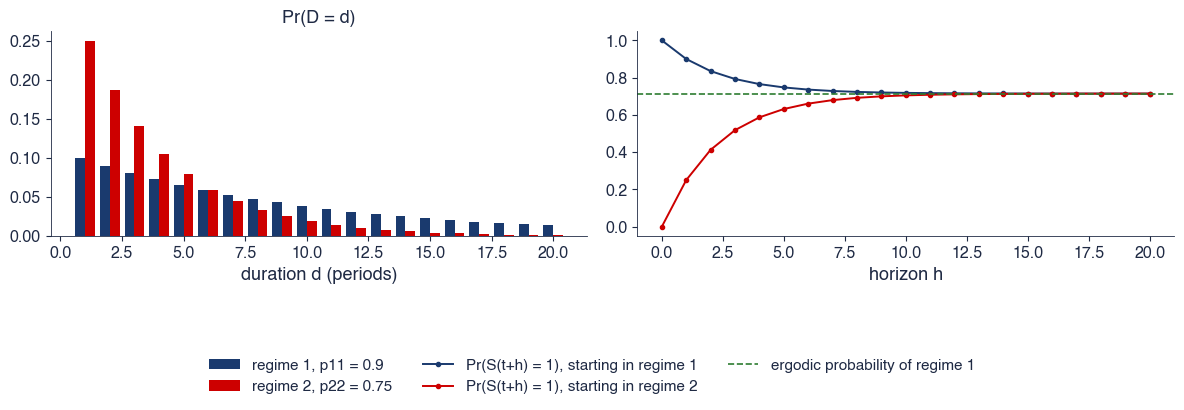

{'pi1': 0.7142857142857153, 'lam': 0.6499999999999999, 'd1': 10.000000000000002, 'd2': 4.0}


In [6]:
def fig_chain(save_it=True, p11=0.9, p22=0.75):
    """Two-regime chain: geometric duration distributions and the convergence of Pr(S_{t+h} = 1 | S_t) to the ergodic
    probability at the rate lambda^h, lambda = p11 + p22 - 1."""
    P = np.array([[p11, 1 - p11], [1 - p22, p22]])
    pi = ergodic(P)
    d = np.arange(1, 21)
    hs = np.arange(0, 21)
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
    axs[0].bar(d - 0.2, p11 ** (d - 1) * (1 - p11), width=0.4, color=st.MainBlue, label=f'regime 1, p11 = {p11}')
    axs[0].bar(d + 0.2, p22 ** (d - 1) * (1 - p22), width=0.4, color=st.IDAred, label=f'regime 2, p22 = {p22}')
    axs[0].set_xlabel('duration d (periods)')
    axs[0].set_title('Pr(D = d)')
    for s0, c, lab in ((0, st.MainBlue, 'starting in regime 1'), (1, st.IDAred, 'starting in regime 2')):
        pr = [np.linalg.matrix_power(P, h)[s0, 0] for h in hs]
        axs[1].plot(hs, pr, 'o-', color=c, ms=3, lw=1.4, label=f'Pr(S(t+h) = 1), {lab}')
    axs[1].axhline(pi[0], color=st.Forest, lw=1.2, ls='--', label='ergodic probability of regime 1')
    axs[1].set_xlabel('horizon h')
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.14, 1, 1))
    save('ats_ch7_chain', save_it)
    return dict(pi1=float(pi[0]), lam=p11 + p22 - 1, d1=1 / (1 - p11), d2=1 / (1 - p22))


print(fig_chain(save_it=False))

## 2. Hamilton (1989): replication and today's data

- Numpy and statsmodels on Hamilton's data; the same model on FRED GDPC1 against the NBER dates.

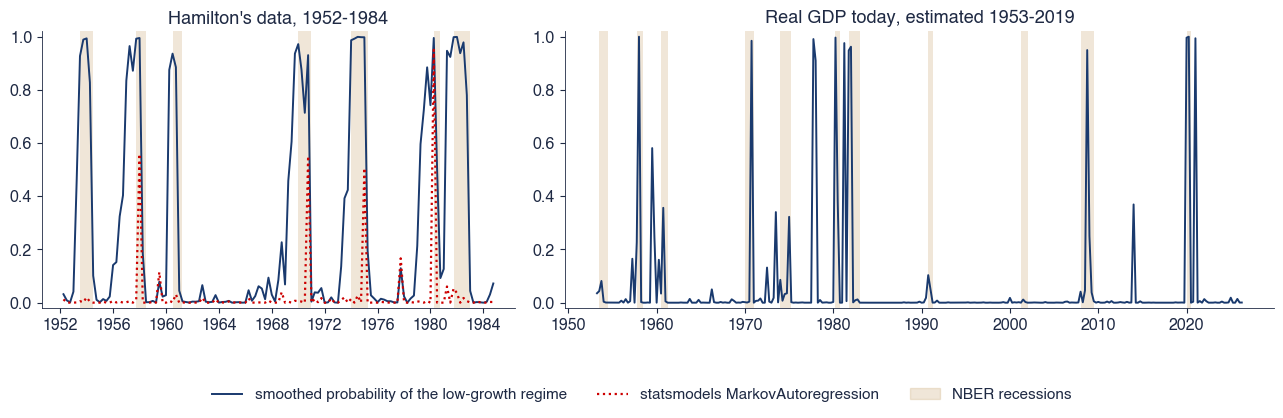

{'mu': [-0.3588128869788483, 1.163516531896824], 'phi': [0.01348706883724888, -0.05752121638528983, -0.24698327832533892, -0.2129214020081043], 'sigma': 0.7690047856576603, 'p00': 0.7546708874164691, 'p11': 0.9040846682119874, 'loglik': -181.2633942625776, 'se': [0.2645396378206941, 0.07451871047823884, 0.11999414283140174, 0.13766306079097176, 0.10691026397357192, 0.11053109130054975, 0.17357395582560364, 0.5213214736360353, 0.4351718440119464], 'dur': [np.float64(4.076157083311974), np.float64(10.425861865443487)], 'T': 131}
{'loglik': -182.49906225745158, 'mu': [0.7801167545695559, -1.4859012386460095], 'sigma': 0.9043811805629101, 'phi': [0.3268023921803221, 0.13396690013665627, -0.09706459213659838, -0.15824589571216147], 'p00': 0.9732838216966291, 'p11': 8.141398666339228e-11, 'maxdiff': 0.9970298115062207}
{'mu': [-1.217268229069942, 0.84177632410502], 'phi': [0.3745762237612847, 0.27066783489966095, -0.21099191944121395, -0.06254521915465241], 'sigma': 0.6713911116948524, 'p00'

In [7]:
def fit_hamilton(y, nrand=8, seed=SEED):
    """Hamilton's switching-mean AR(4) by numerical ML (numpy), regimes ordered so that regime 0 is the low mean."""
    r = msm_fit(np.asarray(y, float), 4, nrand=nrand, seed=seed)
    if r['mu'][0] > r['mu'][1]:
        th = r['theta'].copy()
        th[[0, 1]] = th[[1, 0]]
        th[-2:] = th[-2:][::-1]
        r = msm_fit(np.asarray(y, float), 4, starts=[th], nrand=0)
    return r


def fig_hamilton(save_it=True):
    """Left: Hamilton's data, smoothed probability of the low-growth regime against the NBER recessions.
    Right: the same specification estimated on today's GDP (1952Q2-2019Q4), probabilities through 2026."""
    import statsmodels.api as sm
    y0 = hamilton_gnp()
    r0 = fit_hamilton(y0)
    smr = sm.tsa.MarkovAutoregression(y0.values, k_regimes=2, order=4, switching_ar=False).fit(search_reps=20, disp=False)
    pr = np.asarray(smr.params)
    sm_low = int(np.argmin(pr[2:4]))
    sm_smooth = np.asarray(smr.smoothed_marginal_probabilities)[:, sm_low]
    y, rec = us_gdp()
    ye = y.loc[US['ham_start']:US['est_end']]
    r1 = fit_hamilton(ye)
    yall = y.loc[US['ham_start']:US['end']]
    f, Pe, tup = msm_filter(r1['theta'], yall.values, 2, 4)
    sm_all, _ = kim_smoother(f['filt'], f['pred'], Pe)
    low_all = sm_all[:, tup[:, 0] == 0].sum(1)
    filt_all = f['filt'][:, tup[:, 0] == 0].sum(1)
    idx0 = y0.index[4:]
    idx1 = yall.index[4:]
    rec0 = rec.reindex(idx0).fillna(0)
    rec1 = rec.reindex(idx1)
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw=dict(width_ratios=[1, 1.5]))
    for ax, idx, p, rr, title in ((axs[0], idx0, r0['smooth'][:, 0], rec0, "Hamilton's data, 1952-1984"),
                                  (axs[1], idx1, low_all, rec1, 'Real GDP today, estimated 1953-2019')):
        shade(ax, rr)
        ax.plot(idx, p, color=st.MainBlue, lw=1.4, label='smoothed probability of the low-growth regime')
        ax.set_ylim(-0.02, 1.02)
        ax.set_title(title)
    axs[0].plot(idx0, sm_smooth, ':', color=st.IDAred, lw=1.6, label='statsmodels MarkovAutoregression')
    h, l = axs[0].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h + [patch(st.Amber)], l + ['NBER recessions'], ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch7_hamilton89', save_it)
    est = (rec1.loc[:US['est_end']].values == 1)
    p_est = low_all[:len(est)]
    starts = []
    rc = rec1.values
    for i in range(1, len(rc)):
        if rc[i] == 1 and rc[i - 1] == 0:
            first = next((j for j in range(i - 2, min(i + 8, len(rc))) if low_all[j] > 0.5), None)
            starts.append(dict(nber=str(idx1[i].to_period('Q')), model=str(idx1[first].to_period('Q')) if first is not None else 'none'))
    return dict(
        paper=dict(mu=r0['mu'].tolist(), phi=r0['phi'].tolist(), sigma=float(np.sqrt(r0['sig2'])),
                   p00=float(r0['P'][0, 0]), p11=float(r0['P'][1, 1]), loglik=r0['loglik'], se=r0['se_theta'].tolist(),
                   dur=[1 / (1 - r0['P'][0, 0]), 1 / (1 - r0['P'][1, 1])], T=int(len(y0) - 4)),
        sm=dict(loglik=float(smr.llf), mu=pr[2:4].tolist(), sigma=float(np.sqrt(pr[4])), phi=pr[5:9].tolist(),
                p00=float(pr[0]), p11=float(1 - pr[1]), maxdiff=float(np.max(np.abs(sm_smooth - r0['smooth'][:, 0])))),
        qps_paper=qps(r0['smooth'][:, 0], rec0.values), conc_paper=concordance(r0['smooth'][:, 0] > 0.5, rec0.values),
        today=dict(mu=r1['mu'].tolist(), phi=r1['phi'].tolist(), sigma=float(np.sqrt(r1['sig2'])), p00=float(r1['P'][0, 0]),
                   p11=float(r1['P'][1, 1]), loglik=r1['loglik'], dur=[1 / (1 - r1['P'][0, 0]), 1 / (1 - r1['P'][1, 1])],
                   T=int(len(ye) - 4), qps=qps(p_est, est), conc=concordance(p_est > 0.5, est),
                   nrec=int(est.sum()), p2020=float(low_all[list(idx1).index(pd.Timestamp('2020-04-01'))]),
                   p2008=float(low_all[list(idx1).index(pd.Timestamp('2008-10-01'))]),
                   p2001=float(low_all[list(idx1).index(pd.Timestamp('2001-07-01'))].max()),
                   p2001max=float(low_all[[list(idx1).index(pd.Timestamp(d)) for d in ('2001-01-01', '2001-04-01', '2001-07-01', '2001-10-01')]].max()),
                   last=float(low_all[-1]), lastq=str(idx1[-1].to_period('Q')), filt_last=float(filt_all[-1])),
        starts=starts)


def fig_hamilton_probs():
    """Smoothed low-growth probability of Hamilton's model on today's GDP (estimated 1952Q2-2019Q4)."""
    def get():
        y, _ = us_gdp()
        r1 = fit_hamilton(y.loc[US['ham_start']:US['est_end']])
        yall = y.loc[US['ham_start']:US['end']]
        f, Pe, tup = msm_filter(r1['theta'], yall.values, 2, 4)
        sm_all, _ = kim_smoother(f['filt'], f['pred'], Pe)
        return pd.Series(sm_all[:, tup[:, 0] == 0].sum(1), index=yall.index[4:])
    return cached('ham_probs', get)


r = fig_hamilton(save_it=False)
print(r['paper'])
print(r['sm'])
print(r['today'])

## 3. Dating in pseudo real time

- Re-estimation every 8 quarters here (every 4 on the slides).

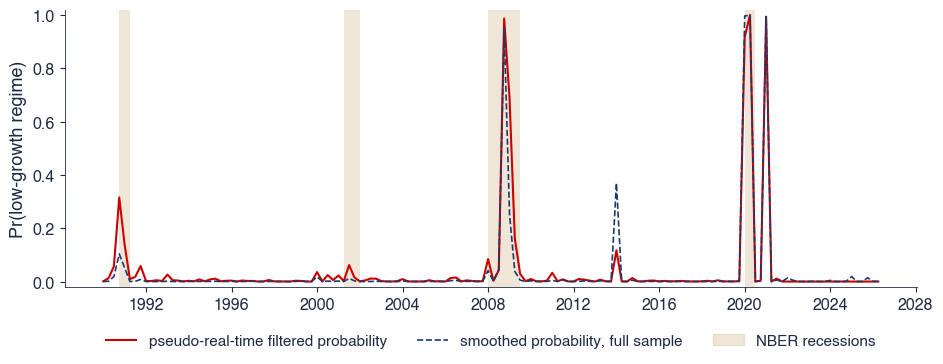

{'qps': 0.1272674883398646, 'qps_smooth': 0.1520873888476255, 'signals': {'1990': {'first': 'none', 'maxp': 0.31562226316729997}, '2001': {'first': 'none', 'maxp': 0.0617735172446965}, '2008': {'first': '2008Q4', 'maxp': 0.9868864320961888}, '2020': {'first': '2020Q1', 'maxp': 0.9999999999998314}}, 'false': 1, 'n': 146}


In [8]:
def fig_realtime(save_it=True, step=4, first='1990-01-01'):
    """Pseudo-real-time filtered probabilities (Chauvet and Piger 2008, without data vintages): Hamilton's model is
    re-estimated every `step` quarters on the data available then; each quarter's filtered probability uses only data
    up to that quarter."""
    y, rec = us_gdp()
    y = y.loc[US['ham_start']:US['end']]
    dates = y.loc[first:].index
    th = None
    out = []
    for i, d in enumerate(dates):
        if i % step == 0:
            yi = y.loc[:d]
            r = msm_fit(yi.values, 4, starts=[th] if th is not None else None, nrand=0 if th is not None else 8, seed=SEED)
            if r['mu'][0] > r['mu'][1]:
                r = fit_hamilton(yi, nrand=8)
            th = r['theta']
        f, Pe, tup = msm_filter(th, y.loc[:d].values, 2, 4)
        out.append(f['filt'][-1, tup[:, 0] == 0].sum())
    p = pd.Series(out, index=dates)
    full = fig_hamilton_probs()
    fig, ax = plt.subplots(figsize=(11, 3.6))
    shade(ax, rec.reindex(dates))
    ax.plot(dates, p.values, color=st.IDAred, lw=1.5, label='pseudo-real-time filtered probability')
    ax.plot(full.loc[first:].index, full.loc[first:].values, color=st.MainBlue, lw=1.2, ls='--',
            label='smoothed probability, full sample')
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel('Pr(low-growth regime)')
    h, l = ax.get_legend_handles_labels()
    ax.legend(h + [patch(st.Amber)], l + ['NBER recessions'], loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
    save('ats_ch7_realtime', save_it)
    r_ = rec.reindex(dates).values
    signals = {}
    for lab, a, b in (('1990', '1990-07-01', '1991-10-01'), ('2001', '2001-01-01', '2002-01-01'),
                      ('2008', '2008-01-01', '2009-10-01'), ('2020', '2020-01-01', '2020-10-01')):
        w = p.loc[a:b]
        hit = w[w > 0.5]
        signals[lab] = dict(first=str(hit.index[0].to_period('Q')) if len(hit) else 'none', maxp=float(w.max()))
    pre = dates < pd.Timestamp('2020-01-01')
    return dict(qps=qps(p.values[pre], r_[pre]), qps_smooth=qps(full.reindex(dates).values[pre], r_[pre]),
                signals=signals, false=int(((p.values > 0.5) & (r_ == 0)).sum()), n=int(len(p)))


print(fig_realtime(save_it=False, step=8))

## 4. EM from many starting values: local and degenerate maxima

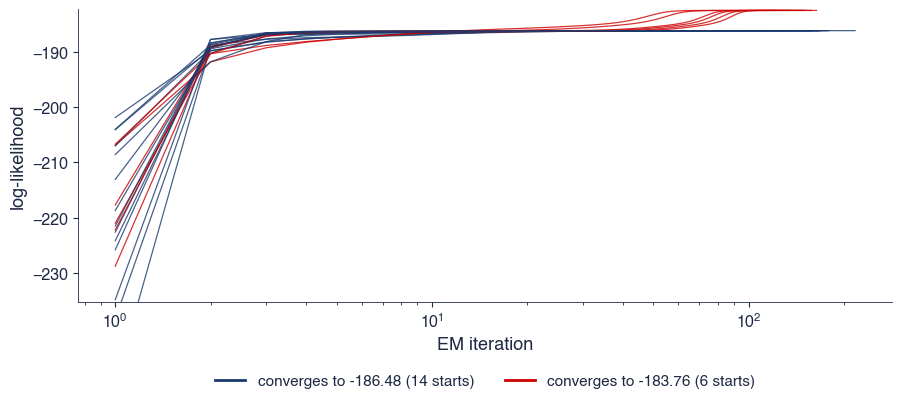

{'groups': [-186.48, -183.76], 'counts': [14, 6], 'iters_med': 157.5, 'iters_max': 216, 'sm_llf': -185.7295176472857, 'degenerate': {'sig2': [0.04923130024711621, 1.0872187563868503], 'P': [1.5880756696131978e-10, 0.7587504937463869], 'beta': [1.1076308793069205, 0.25586602608596903], 'share': 0.19652752424492803, 'n_hi': 29}, 'n': 20, 'second': {'P': [0.8462455361094148, 0.7611171712542141], 'sig2': [0.5560361868028906, 1.1102729867873382], 'beta': [0.9866481315689711, -0.038201645851826095]}}


In [9]:
def fig_em(save_it=True, starts=30):
    """EM (Hamilton 1990) for an MSIH(2)-AR(1) on Hamilton's data from many random starting values: the path of the
    log-likelihood, and the solutions it converges to."""
    import statsmodels.api as sm
    y0 = hamilton_gnp()
    ys, X = lag_design(y0.values, 1)
    rng = np.random.default_rng(SEED)
    runs = [em_msr(ys, X, 2, switch=[True, False], rng=rng, maxit=3000, tol=1e-10) for _ in range(starts)]
    fins = np.array([r['loglik'] for r in runs])
    groups = np.unique(np.round(fins, 2))
    smr = sm.tsa.MarkovRegression(ys, k_regimes=2, exog=X[:, 1:], switching_exog=False, switching_variance=True).fit(
        search_reps=20, disp=False)
    fig, ax = plt.subplots(figsize=(10.5, 3.8))
    cols = [st.MainBlue, st.IDAred, st.Forest, st.Purple, st.Orange, st.Teal]
    for r in runs:
        g = int(np.argmin(np.abs(groups - round(r['loglik'], 2))))
        ax.plot(np.arange(1, len(r['path']) + 1), r['path'], color=cols[g % len(cols)], lw=0.9, alpha=0.8)
    for g, v in enumerate(groups):
        ax.plot([], [], color=cols[g % len(cols)], lw=2, label=f'converges to {v:.2f} ({int((np.round(fins, 2) == v).sum())} starts)')
    ax.set_xscale('log')
    lo = np.percentile([r['path'][0] for r in runs], 10)
    ax.set_ylim(lo, groups.max() + 1.5)
    ax.set_xlabel('EM iteration')
    ax.set_ylabel('log-likelihood')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    save('ats_ch7_em', save_it)
    best = runs[int(np.argmax(fins))]
    bo = order_regimes(best, 'var')
    deg = dict(sig2=bo['sig2'].tolist(), P=np.diag(bo['P']).tolist(), beta=bo['beta'][:, 0].tolist(),
               share=float(bo['smooth'][:, 0].mean()), n_hi=int((bo['smooth'][:, 0] > 0.5).sum()))
    good = [r for r in runs if abs(r['loglik'] - groups[groups < groups.max() - 0.5].max()) < 0.01] if (groups < groups.max() - 0.5).any() else []
    return dict(groups=groups.tolist(), counts=[int((np.round(fins, 2) == v).sum()) for v in groups],
                iters_med=float(np.median([r['iters'] for r in runs])), iters_max=int(max(r['iters'] for r in runs)),
                sm_llf=float(smr.llf), degenerate=deg, n=starts,
                second=dict(P=np.diag(good[0]['P']).tolist(), sig2=good[0]['sig2'].tolist(), beta=good[0]['beta'][:, 0].tolist()) if good else None)


print(fig_em(save_it=False, starts=20))

## 5. How many regimes? Bootstrap of the LR statistic

- B = 49 here (199 on the slides).

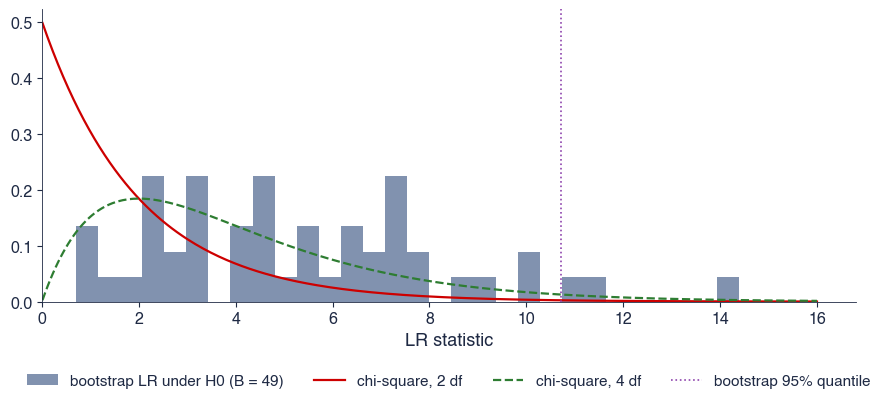

{'LR': 71.69425461011417, 'p': 0.02, 'q95': 10.723380621715176, 'c2': 5.99146454710798, 'c4': 9.487729036781154, 'B': 49, 'mean_sim': 5.342789381144859, 'share_zero': 0.0, 'ic': {'1': {'loglik': -369.2250560563879, 'npar': 3, 'AIC': 744.4501121127759, 'BIC': np.float64(755.4597548817175), 'HQ': np.float64(748.8611208104626)}, '2': {'loglik': -333.37792094159124, 'npar': 7, 'AIC': 680.7558418831825, 'BIC': np.float64(706.4450083440461), 'HQ': np.float64(691.0481955111183)}, '3': {'loglik': -330.47595659638114, 'npar': 13, 'AIC': 686.9519131927623, 'BIC': np.float64(734.6603651915091), 'HQ': np.float64(706.0662842160716)}}, 'sig': [0.4624607635711332, 1.107662640193962], 'P': [0.9901166435820531, 0.9846800677783841], 'mu': [0.7248120226060151, 0.835110772582366], 'T': 290}


In [10]:
def lr_bootstrap(y, p=1, B=199, starts=4, seed=SEED, maxit=400):
    """H0: Gaussian AR(p) (one regime); H1: MSIH(2)-AR(p). The LR statistic has no chi-square limit (the transition
    probabilities are not identified under H0 and the score is degenerate), so its null distribution is simulated:
    data from the estimated AR(p), both models re-estimated on every simulated sample."""
    y = np.asarray(y, float)
    ys, X = lag_design(y, p)
    r0 = linear_ar(ys, X)
    r1 = best_em(ys, X, 2, starts=10, switch=[True] + [False] * p, seed=seed)
    LR = 2 * (r1['loglik'] - r0['loglik'])
    rng = np.random.default_rng(seed)
    c, phi = r0['beta'][0], r0['beta'][1:]
    s = np.sqrt(r0['sig2'])
    sims = []
    for b in range(B):
        n = len(y) + 100
        z = np.zeros(n)
        e = rng.normal(0, s, n)
        z[:p] = np.mean(y)
        for t in range(p, n):
            z[t] = c + phi @ z[t - p:t][::-1] + e[t]
        z = z[100:]
        zs, Z = lag_design(z, p)
        l0 = linear_ar(zs, Z)['loglik']
        l1 = best_em(zs, Z, 2, starts=starts, switch=[True] + [False] * p, seed=seed + b + 1, order=None, maxit=maxit)['loglik']
        sims.append(max(0.0, 2 * (l1 - l0)))
    sims = np.array(sims)
    return dict(LR=float(LR), sims=sims, p=float((1 + (sims >= LR).sum()) / (B + 1)), q95=float(np.quantile(sims, 0.95)),
                r0=r0, r1=r1)


def regime_ic(y, p=1, Ks=(1, 2, 3), starts=15):
    y = np.asarray(y, float)
    ys, X = lag_design(y, p)
    out = {}
    for K in Ks:
        if K == 1:
            r = linear_ar(ys, X)
        else:
            r = best_em(ys, X, K, starts=starts, switch=[True] + [False] * p, seed=SEED)
        out[K] = dict(loglik=float(r['loglik']), npar=int(r['npar']), **info_criteria(r['loglik'], r['npar'], len(ys)))
    return out


def fig_lrtest(save_it=True, B=199):
    """US GDP growth 1947Q2-2019Q4: AR(1) against MSIH(2)-AR(1); the bootstrap distribution of the LR statistic
    compared with chi-square distributions with 2 and 4 degrees of freedom."""
    y, _ = us_gdp()
    y = y.loc[US['start']:US['est_end']]
    bt = lr_bootstrap(y.values, 1, B=B)
    ic = regime_ic(y.values)
    fig, ax = plt.subplots(figsize=(10.5, 3.8))
    ax.hist(bt['sims'], bins=30, density=True, color=st.MainBlue, alpha=0.55, label=f'bootstrap LR under H0 (B = {B})')
    xs = np.linspace(0.01, max(bt['sims'].max(), 16), 300)
    ax.plot(xs, stats.chi2.pdf(xs, 2), color=st.IDAred, lw=1.6, label='chi-square, 2 df')
    ax.plot(xs, stats.chi2.pdf(xs, 4), color=st.Forest, lw=1.6, ls='--', label='chi-square, 4 df')
    ax.axvline(bt['q95'], color=st.Purple, lw=1.2, ls=':', label='bootstrap 95% quantile')
    ax.set_xlabel('LR statistic')
    ax.set_xlim(0, max(bt['sims'].max(), 16) * 1.05)
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    save('ats_ch7_lrtest', save_it)
    r1 = bt['r1']
    return dict(LR=bt['LR'], p=bt['p'], q95=bt['q95'], c2=float(stats.chi2.ppf(0.95, 2)), c4=float(stats.chi2.ppf(0.95, 4)),
                B=B, mean_sim=float(bt['sims'].mean()), share_zero=float((bt['sims'] < 1e-6).mean()),
                ic={str(k): v for k, v in ic.items()}, sig=np.sqrt(r1['sig2']).tolist(), P=np.diag(r1['P']).tolist(),
                mu=(r1['beta'][:, 0] / (1 - r1['beta'][0, 1])).tolist(), T=int(len(y) - 1))


print(fig_lrtest(save_it=False, B=49))

## 6. Time-varying transition probabilities: Filardo (1994)

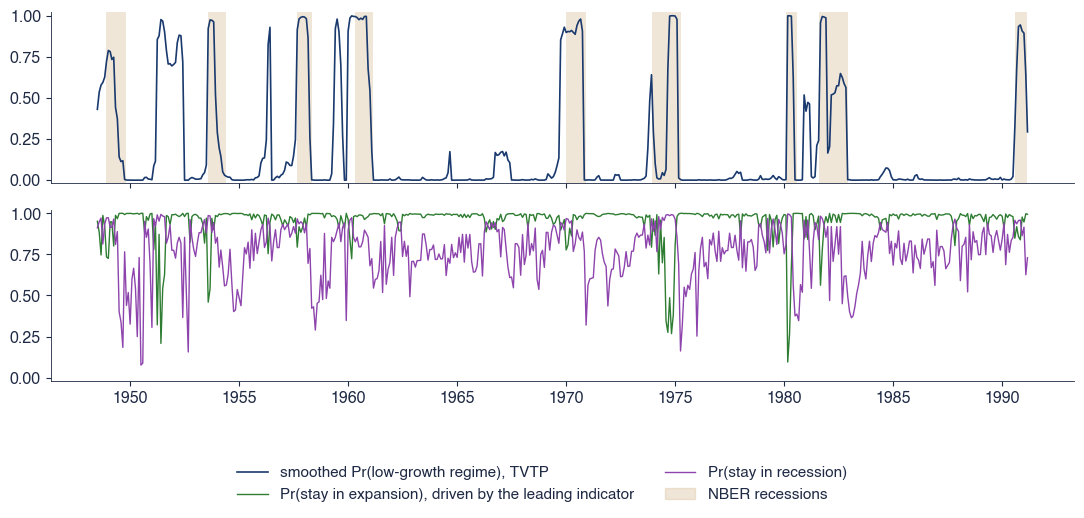

{'loglik': -586.1999376017277, 'loglik_const': -590.6687148941235, 'LR': 8.937554584791542, 'pLR': 0.011461321131080822, 'sm_llf': -586.1999376017278, 'sm_search': -590.7822441222366, 'mu': [-0.8680394732046246, 0.5017643224557079], 'sigma': 0.6996970673469954, 'gamma': [1.4881804067194746, -1.089793169903369, 4.3305895610184795, 1.748671433815077], 'se_gamma': [0.4835760768342231, 0.6222149336136411, 0.762773914365248, 0.5221729923358681], 'T': 513, 'start': '1948-07', 'end': '1991-03', 'stay_exp_min': 0.09524191706057558, 'stay_exp_med': 0.9878131536054319, 'p_const': [0.9832121333765226, 0.14472374809825939], 'mu_const': [0.19519741040765387, 2.7726099432074838], 'share_rec': 0.19298245614035087, 'qps': 0.19676581711922586, 'conc': 0.8771929824561403}


In [11]:
def fig_tvtp(save_it=True):
    """Filardo (1994): switching-mean AR(4) for US industrial production growth, Pr(S_t = i | S_{t-1} = i) logistic in
    the lagged growth of the leading indicator; numpy ML against statsmodels; constant transitions for comparison."""
    import statsmodels.api as sm
    d = filardo_data()
    y = d['dlip'].iloc[2:]
    z = d['dmdlleading'].iloc[1:-1]
    Z = np.column_stack([np.ones(len(z)), z.values])
    r = msm_fit(y.values, 4, Z=Z, nrand=10, seed=SEED)
    if r['mu'][0] > r['mu'][1]:
        th = r['theta'].copy()
        th[[0, 1]] = th[[1, 0]]
        th[-4:] = np.r_[th[-2:], th[-4:-2]]
        r = msm_fit(y.values, 4, Z=Z, starts=[th], nrand=0)
    rc = fit_hamilton(y)
    th = r['theta']
    start = np.r_[th[7], -th[9], th[8], -th[10], th[0:2], np.exp(th[6]), th[2:6]]     # statsmodels ordering
    smm = sm.tsa.MarkovAutoregression(y.values, k_regimes=2, order=4, switching_ar=False, exog_tvtp=sm.add_constant(z.values))
    smr = smm.fit(start_params=start, disp=False)
    sm_search = smm.fit(search_reps=20, disp=False)
    idx = y.index[4:]
    stay_exp = r['P'][4:, 1, 1]
    stay_rec = r['P'][4:, 0, 0]
    fig, axs = plt.subplots(2, 1, figsize=(11, 4.8), sharex=True)
    usrec = cached('usrec_m', lambda: read_fred('USREC'))
    shade(axs[0], usrec.reindex(idx).fillna(0))
    axs[0].plot(idx, r['smooth'][:, 0], color=st.MainBlue, lw=1.2, label='smoothed Pr(low-growth regime), TVTP')
    axs[0].set_ylim(-0.02, 1.02)
    axs[1].plot(idx, stay_exp, color=st.Forest, lw=1.0, label='Pr(stay in expansion), driven by the leading indicator')
    axs[1].plot(idx, stay_rec, color=st.Purple, lw=1.0, label='Pr(stay in recession)')
    axs[1].set_ylim(-0.02, 1.02)
    h, l = [], []
    for ax in axs:
        hh, ll = ax.get_legend_handles_labels()
        h += hh
        l += ll
    st.fig_legend_bottom(fig, h + [patch(st.Amber)], l + ['NBER recessions'], ncol=2, y=0.04)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save('ats_ch7_tvtp', save_it)
    rr = usrec.reindex(idx).fillna(0).values
    LR = 2 * (r['loglik'] - rc['loglik'])
    g = r['theta'][-4:]
    return dict(loglik=r['loglik'], loglik_const=rc['loglik'], LR=float(LR), pLR=float(stats.chi2.sf(LR, 2)),
                sm_llf=float(smr.llf), sm_search=float(sm_search.llf), mu=r['mu'].tolist(), sigma=float(np.sqrt(r['sig2'])), gamma=g.tolist(),
                se_gamma=r['se_theta'][-4:].tolist(), T=int(len(idx)), start=str(idx[0])[:7], end=str(idx[-1])[:7],
                stay_exp_min=float(stay_exp.min()), stay_exp_med=float(np.median(stay_exp)),
                p_const=[float(rc['P'][0, 0]), float(rc['P'][1, 1])], mu_const=rc['mu'].tolist(),
                share_rec=float((r['smooth'][:, 0] > 0.5).mean()), qps=qps(r['smooth'][:, 0], rr),
                conc=concordance(r['smooth'][:, 0] > 0.5, rr))


print(fig_tvtp(save_it=False))

## 7. Markov-switching VAR and regime-dependent impulse responses

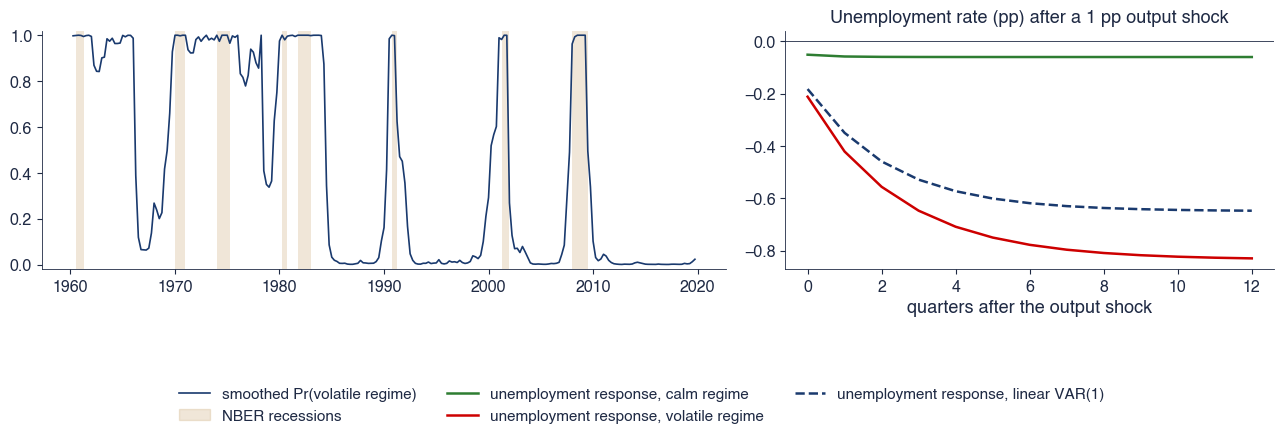

{'loglik': -166.76946622278282, 'npar': 20, 'T': 239, 'P': [0.954134118430274, 0.9298588846584916], 'dur': [21.8026987768628, 14.256973176590144], 'sd_y': [0.419829113058246, 1.0195353772180995], 'sd_u': [0.13920334191532815, 0.31191883077748667], 'corr': [-0.1524594438645729, -0.6902363337317462], 'a11': [0.08471194802340673, 0.08053932526597449], 'u_h4': [-0.059373348284624, -0.708320995822274, -0.5724230678273023], 'u_h12': [-0.059427968562548485, -0.8292383041342714, -0.6470134944742534], 'shock': [1.0, 1.0, 1.0], 'share_lo': 0.4289459229807608, 'qps': 0.5109626833980095, 'rec_in_vol': 0.9960983928126832, 'vol_pre84': 0.8287203237377292, 'vol_post84': 0.16520586692581643, 'mean_g': [0.7879445524109654, 0.8122625350213831], 'll_lin': -222.03353710602667, 'iters': 34}


In [12]:
def us_var_data(start='1960-01-01', end=US['est_end']):
    y, rec = us_gdp()
    u = us_unemp_q()
    D = pd.concat([y, u.diff().rename('du')], axis=1).loc[start:end].dropna()
    return D, rec.reindex(D.index)


def fig_msvar(save_it=True, H=12):
    """MSIAH(2)-VAR(1) for US GDP growth and the change of the unemployment rate (quarterly, 1960-2019); regime-dependent
    responses of the unemployment rate (cumulated) to a one-standard-deviation output shock (Cholesky, output first)."""
    D, rec = us_var_data()
    r = em_msvar(D.values, 1, K=2, seed=SEED, starts=12)
    hi = int(np.argmax([s[0, 0] for s in r['S']]))      # volatile regime: larger variance of the output shock
    lo = 1 - hi
    Yt, X = var_design(D.values, 1)
    Bl = np.linalg.lstsq(X, Yt, rcond=None)[0]
    Sl = np.cov((Yt - X @ Bl).T, bias=True)
    irf = {k: regime_irf(r['B'][j], r['S'][j], 2, 1, H) for k, j in (('lo', lo), ('hi', hi))}
    irf['lin'] = regime_irf(Bl, Sl, 2, 1, H)
    irf = {k: v / v[0, 0] for k, v in irf.items()}          # scaled to a 1 pp output shock on impact
    idx = D.index[1:]
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw=dict(width_ratios=[1.4, 1]))
    shade(axs[0], rec.iloc[1:])
    axs[0].plot(idx, r['smooth'][:, hi], color=st.MainBlue, lw=1.2, label='smoothed Pr(volatile regime)')
    axs[0].set_ylim(-0.02, 1.02)
    hs = np.arange(H + 1)
    for k, c, lab in (('lo', st.Forest, 'calm regime'), ('hi', st.IDAred, 'volatile regime'), ('lin', st.MainBlue, 'linear VAR(1)')):
        axs[1].plot(hs, np.cumsum(irf[k][:, 1]), color=c, lw=1.8, ls='--' if k == 'lin' else '-', label=f'unemployment response, {lab}')
    axs[1].axhline(0, color=st.DarkText, lw=0.6)
    axs[1].set_xlabel('quarters after the output shock')
    axs[1].set_title('Unemployment rate (pp) after a 1 pp output shock')
    h0, l0 = axs[0].get_legend_handles_labels()
    h1, l1 = axs[1].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h0 + [patch(st.Amber)] + h1, l0 + ['NBER recessions'] + l1, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.12, 1, 1))
    save('ats_ch7_msvar', save_it)
    mean_g = [float(b[0, 0] / (1 - b[1, 0])) for b in r['B']]
    return dict(loglik=r['loglik'], npar=r['npar'], T=r['T'], P=[float(r['P'][lo, lo]), float(r['P'][hi, hi])],
                dur=[float(1 / (1 - r['P'][lo, lo])), float(1 / (1 - r['P'][hi, hi]))],
                sd_y=[float(np.sqrt(r['S'][lo][0, 0])), float(np.sqrt(r['S'][hi][0, 0]))],
                sd_u=[float(np.sqrt(r['S'][lo][1, 1])), float(np.sqrt(r['S'][hi][1, 1]))],
                corr=[float(r['S'][j][0, 1] / np.sqrt(r['S'][j][0, 0] * r['S'][j][1, 1])) for j in (lo, hi)],
                a11=[float(r['B'][lo][1, 0]), float(r['B'][hi][1, 0])],
                u_h4=[float(np.cumsum(irf[k][:, 1])[4]) for k in ('lo', 'hi', 'lin')],
                u_h12=[float(np.cumsum(irf[k][:, 1])[H]) for k in ('lo', 'hi', 'lin')],
                shock=[float(irf[k][0, 0]) for k in ('lo', 'hi', 'lin')],
                share_lo=float(r['smooth'][:, hi].mean()), qps=qps(r['smooth'][:, hi], rec.iloc[1:].values),
                rec_in_vol=float(r['smooth'][rec.iloc[1:].values == 1, hi].mean()),
                vol_pre84=float(r['smooth'][idx < pd.Timestamp('1984-01-01'), hi].mean()),
                vol_post84=float(r['smooth'][idx >= pd.Timestamp('1984-01-01'), hi].mean()),
                mean_g=[float(r['B'][j][0, 0] / (1 - r['B'][j][1, 0])) for j in (lo, hi)],
                ll_lin=float(-0.5 * len(Yt) * (np.log(np.linalg.det(Sl)) + 2 * np.log(2 * np.pi) + 2)), iters=r['iters'])


print(fig_msvar(save_it=False))

## 8. MS-GARCH: Haas–Mittnik–Paolella and Gray

- Sample from 2015 here (2000 on the slides).

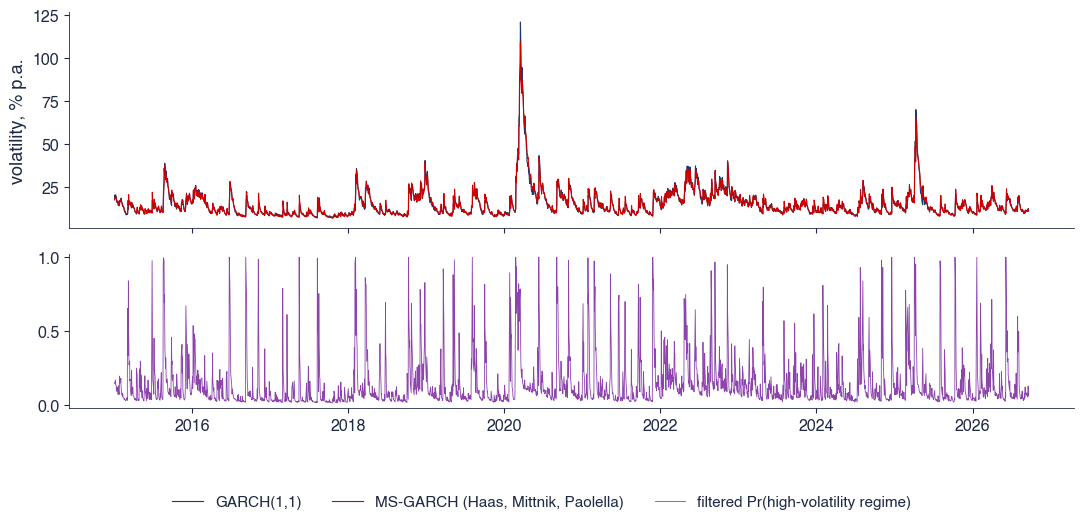

{'garch': {'loglik': -3796.104948613486, 'npar': 4, 'bic': 7624.158636219906, 'omega': [0.041126836573919884], 'alpha': [0.1680498667123903], 'beta': [0.7964720000919822], 'pers': [0.9645218668043725], 'P': [1.0]}, 'hmp': {'loglik': -3688.602426694078, 'npar': 9, 'bic': 7449.089516122257, 'omega': [0.011352968807509363, 0.20487690699625352], 'alpha': [0.08732972571220438, 0.13959484241370826], 'beta': [0.8680363538705698, 0.859401559244031], 'pers': [0.9553660795827741, 0.9989964016577393], 'P': [0.9534567955744153, 0.7457707261944457]}, 'gray': {'loglik': -3764.730190034149, 'npar': 9, 'bic': 7601.345042802399, 'omega': [0.07014463006708037, 0.18036209752914714], 'alpha': [0.057594041649664016, 0.1113685488723739], 'beta': [0.28246556812991136, 0.8875061719893859], 'pers': [0.3400596097795754, 0.9988747208617598], 'P': [0.8656612454797709, 0.9366526778385833]}, 'hi': 1, 'lo': 0, 'T': 2943, 'start': '2015-01-05', 'end': '2026-09-18', 'uncond': [12.77434048470455, 29.388346844033112], '

In [13]:
def fig_msgarch(save_it=True, start=MARKET['start']):
    """S&P 500 daily log returns: GARCH(1,1), MS-GARCH(1,1) of Haas, Mittnik and Paolella (2004) and of Gray (1996)."""
    r = load_close('sp500', start, MARKET['end'])
    ret = (100 * np.log(r).diff()).dropna()
    x = ret.values
    g1 = msgarch_fit(x, K=1)
    hmp = msgarch_fit(x, K=2, kind='hmp')
    gray = msgarch_fit(x, K=2, kind='gray')
    hi = int(np.argmax(hmp['omega'] / (1 - hmp['alpha'] - hmp['beta'])))
    ann = np.sqrt(252)
    fig, axs = plt.subplots(2, 1, figsize=(11, 5.0), sharex=True, gridspec_kw=dict(height_ratios=[1.4, 1]))
    axs[0].plot(ret.index, ann * np.sqrt(g1['h'][:, 0]), color=st.MainBlue, lw=0.8, label='GARCH(1,1)')
    axs[0].plot(ret.index, ann * np.sqrt(hmp['hmix']), color=st.IDAred, lw=0.8, label='MS-GARCH (Haas, Mittnik, Paolella)')
    axs[0].set_ylabel('volatility, % p.a.')
    axs[1].plot(ret.index, hmp['filt'][:, hi], color=st.Purple, lw=0.6, label='filtered Pr(high-volatility regime)')
    axs[1].set_ylim(-0.02, 1.02)
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch7_msgarch', save_it)
    T = len(x)
    out = {}
    for k, m in (('garch', g1), ('hmp', hmp), ('gray', gray)):
        out[k] = dict(loglik=float(m['loglik']), npar=int(m['npar']), bic=float(-2 * m['loglik'] + m['npar'] * np.log(T)),
                      omega=m['omega'].tolist(), alpha=m['alpha'].tolist(), beta=m['beta'].tolist(),
                      pers=(m['alpha'] + m['beta']).tolist(), P=np.diag(m['P']).tolist())
    lo = 1 - hi
    out.update(hi=hi, lo=lo, T=T, start=str(ret.index[0].date()), end=str(ret.index[-1].date()),
               uncond=[float(ann * np.sqrt(hmp['h'][hmp['filt'][:, j] > 0.5, j]).mean()) for j in (lo, hi)],
               share_hi=float((hmp['filt'][:, hi] > 0.5).mean()),
               dur=[float(1 / (1 - hmp['P'][lo, lo])), float(1 / (1 - hmp['P'][hi, hi]))])
    return out


print(fig_msgarch(save_it=False, start='2015-01-01'))

## 9. Bull and bear regimes of the S&P 500 and the BET; regime-dependent allocation

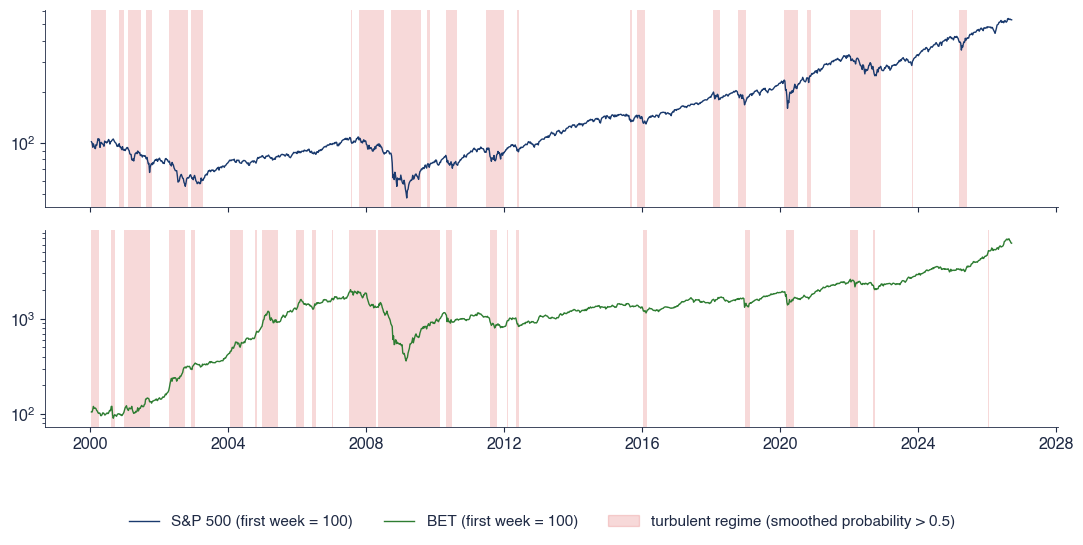

{'sp500': {'mu': [0.3197106145884604, -0.39521673548295466], 'sd': [1.514791799179225, 3.9293872039587017], 'ann_mu': [16.62495195859994, -20.551270245113642], 'ann_sd': [10.923319007186091, 28.33521409005035], 'P': [0.9728119644750562, 0.9304202392582427], 'dur': [36.78088470505884, 14.371995381120419], 'loglik': -3019.326811260278, 'sm_llf': -3019.3268116267795, 'se': [0.05291153583130916, 0.20821844512081747, 0.16009568163849044, 1.5074693324727508, 0.0077826882207904045, 0.020610175296428484], 'share_turb': 0.26202440775305097, 'w': [2.7866418846917607, -0.5119359980648681], 'w_const': 0.3946060614562429, 'w_t_min': -0.474598281729992, 'w_t_max': 2.0189929967158813, 'T': 1393, 'last': 0.020086693395436186}, 'bet': {'mu': [0.3869492623922151, 0.061240640841984176], 'sd': [1.8917691045719973, 5.537454076915516], 'ann_mu': [20.121361644395186, 3.184513323783177], 'ann_sd': [13.641741015745867, 39.93114921969201], 'P': [0.9693291216567098, 0.9177701420961446], 'dur': [32.6042178775349,

In [14]:
def fit_bullbear(name):
    r = weekly_returns(name)
    ys, X = r.values, np.ones((len(r), 1))
    e = best_em(ys, X, 2, starts=15, seed=SEED, order='var', polish=True)
    return r, e


def fig_bullbear(save_it=True, gamma=5.0):
    """Two regimes in mean and variance for weekly S&P 500 and BET log returns; regime 1 = calm, regime 2 = turbulent.
    Ang and Bekaert (2002), briefly: mean-variance weight of equity against cash, w = mu / (gamma sigma^2), by regime."""
    import statsmodels.api as sm
    fig, axs = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True)
    out = {}
    probs = {}
    for ax, name, lab in ((axs[0], 'sp500', 'S&P 500'), (axs[1], 'bet', 'BET')):
        r, e = fit_bullbear(name)
        lvl = np.exp(np.cumsum(r.values) / 100)
        shade(ax, pd.Series(e['smooth'][:, 1] > 0.5, index=r.index), color=st.IDAred, alpha=0.15)
        ax.plot(r.index, 100 * lvl, color=st.MainBlue if name == 'sp500' else st.Forest, lw=1.0, label=f'{lab} (first week = 100)')
        ax.set_yscale('log')
        smr = sm.tsa.MarkovRegression(r.values, k_regimes=2, switching_variance=True).fit(search_reps=20, disp=False)
        mu, s = e['beta'][:, 0], np.sqrt(e['sig2'])
        w = 100 * mu / (gamma * s ** 2)                     # returns in %: weight as a fraction of wealth
        xi = e['filt'] @ e['P']
        m_t = xi @ mu
        v_t = xi @ (s ** 2 + mu ** 2) - m_t ** 2
        probs[name] = pd.Series(e['smooth'][:, 1], index=r.index)
        out[name] = dict(mu=mu.tolist(), sd=s.tolist(), ann_mu=(52 * mu).tolist(), ann_sd=(np.sqrt(52) * s).tolist(),
                         P=np.diag(e['P']).tolist(), dur=(1 / (1 - np.diag(e['P']))).tolist(), loglik=float(e['loglik']),
                         sm_llf=float(smr.llf), se=e['se'].tolist(), share_turb=float((e['smooth'][:, 1] > 0.5).mean()),
                         w=w.tolist(), w_const=float(100 * np.mean(r.values) / (gamma * np.var(r.values))),
                         w_t_min=float((100 * m_t / (gamma * v_t)).min()), w_t_max=float((100 * m_t / (gamma * v_t)).max()),
                         T=int(len(r)), last=float(e['filt'][-1, 1]))
    h0, l0 = axs[0].get_legend_handles_labels()
    h1, l1 = axs[1].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h0 + h1 + [patch(st.IDAred, 0.15)], l0 + l1 + ['turbulent regime (smoothed probability > 0.5)'], ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch7_bullbear', save_it)
    j = pd.concat(probs, axis=1).dropna()
    out['corr_turb'] = float(j.corr().iloc[0, 1])
    out['both_turb'] = float(((j > 0.5).all(axis=1)).mean())
    out['gamma'] = gamma
    return out


print(fig_bullbear(save_it=False))

## 10. Bayesian estimation: Gibbs sampling, FFBS and label switching

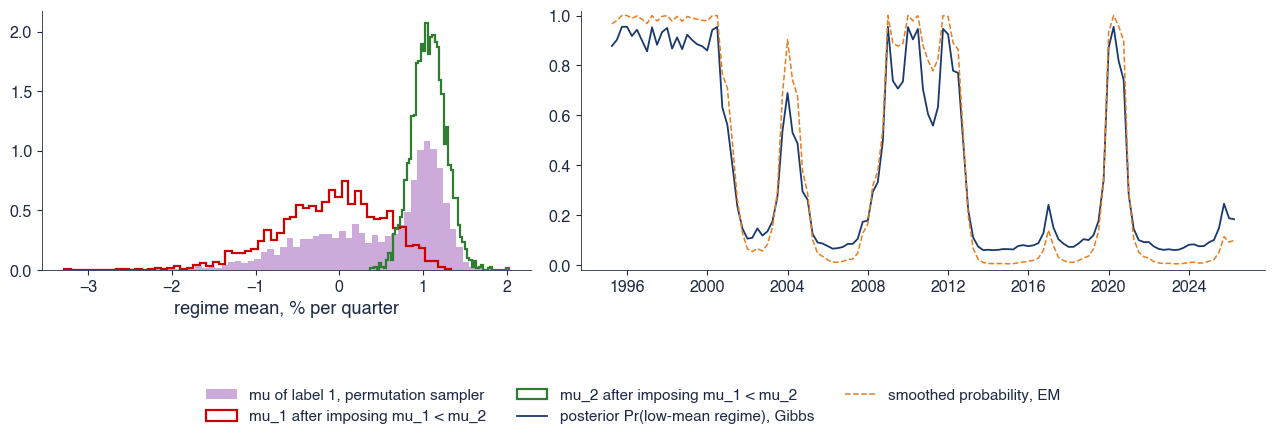

{'T': 125, 'start': '1995Q2', 'end': '2026Q2', 'mu1': [-0.13491965583693483, -1.281144080640634, 0.8158281796317485], 'mu2': [1.0725335253593968, 0.7535545063329213, 1.4075421453934511], 'sd1': [3.82151843675916, 2.9983507618664103, 4.7733202087310485], 'sd2': [1.5327256809183896, 1.172910388238936, 1.9008674949324755], 'p11': [0.8509150908737636, 0.7181561614927077, 0.9392337153392342], 'p22': [0.9046278023350786, 0.8079648710208902, 0.9681109444630813], 'em_mu': [0.03386946930464417, 1.0376132938764546], 'em_sd': [3.923703953112481, 1.310336256846164], 'em_P': [0.9004792803176854, 0.9433193543122285], 'share_swapped': 0.502, 'acf1': 0.26126496364409735, 'n_kept': 2500, 'lo_quarters': ['1995Q2', '1995Q3', '1995Q4', '1996Q1', '1996Q2', '1996Q3', '1996Q4', '1997Q1', '1997Q2', '1997Q3', '1997Q4', '1998Q1', '1998Q2', '1998Q3', '1998Q4', '1999Q1', '1999Q2', '1999Q3', '1999Q4', '2000Q1', '2000Q2', '2000Q3', '2000Q4', '2001Q1', '2003Q4', '2004Q1', '2004Q2', '2009Q1', '2009Q2', '2009Q3', '200

In [15]:
def fig_gibbs(save_it=True, n_iter=6000, burn=1000):
    """Romanian quarterly GDP growth: two regimes in mean and variance. Gibbs sampler with FFBS (Chib 1996), once with
    the random permutation sampler (label switching made visible), once identified by mu_1 < mu_2; EM for comparison."""
    y = ro_gdp()
    g_perm = gibbs_ms(y.values, 2, n_iter=n_iter, burn=burn, seed=SEED, permute=True)
    g_id = gibbs_ms(y.values, 2, n_iter=n_iter, burn=burn, seed=SEED + 1, permute=False)
    e = best_em(y.values, np.ones((len(y), 1)), 2, starts=15, seed=SEED, order='mean')
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw=dict(width_ratios=[1, 1.4]))
    axs[0].hist(g_perm['mu'][:, 0], bins=60, density=True, color=st.Purple, alpha=0.45, label='mu of label 1, permutation sampler')
    axs[0].hist(g_perm['mu_id'][:, 0], bins=60, density=True, histtype='step', color=st.IDAred, lw=1.6, label='mu_1 after imposing mu_1 < mu_2')
    axs[0].hist(g_perm['mu_id'][:, 1], bins=60, density=True, histtype='step', color=st.Forest, lw=1.6, label='mu_2 after imposing mu_1 < mu_2')
    axs[0].set_xlabel('regime mean, % per quarter')
    axs[1].plot(y.index, g_id['prob'][:, 0], color=st.MainBlue, lw=1.3, label='posterior Pr(low-mean regime), Gibbs')
    axs[1].plot(y.index, e['smooth'][:, 0], color=st.Orange, lw=1.1, ls='--', label='smoothed probability, EM')
    axs[1].set_ylim(-0.02, 1.02)
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.12, 1, 1))
    save('ats_ch7_gibbs', save_it)
    mu = g_id['mu_id']
    sd = np.sqrt(g_id['sig2_id'])
    P = g_id['P_id']
    q = lambda a: [float(np.mean(a)), float(np.quantile(a, 0.05)), float(np.quantile(a, 0.95))]
    lab_sw = float(np.mean(g_perm['mu'][:, 0] > g_perm['mu'][:, 1]))
    acf1 = float(acf(mu[:, 0], 1)[1])
    return dict(T=int(len(y)), start=str(y.index[0].to_period('Q')), end=str(y.index[-1].to_period('Q')),
                mu1=q(mu[:, 0]), mu2=q(mu[:, 1]), sd1=q(sd[:, 0]), sd2=q(sd[:, 1]), p11=q(P[:, 0, 0]), p22=q(P[:, 1, 1]),
                em_mu=e['beta'][:, 0].tolist(), em_sd=np.sqrt(e['sig2']).tolist(), em_P=np.diag(e['P']).tolist(),
                share_swapped=lab_sw, acf1=acf1, n_kept=int(n_iter - burn),
                lo_quarters=[str(i.to_period('Q')) for i in y.index[g_id['prob'][:, 0] > 0.5]][:60],
                n_lo=int((g_id['prob'][:, 0] > 0.5).sum()), corr_em=float(np.corrcoef(g_id['prob'][:, 0], e['smooth'][:, 0])[0, 1]))


print(fig_gibbs(save_it=False, n_iter=3000, burn=500))

## 11. Regime switching and long memory (Diebold and Inoue 2001)

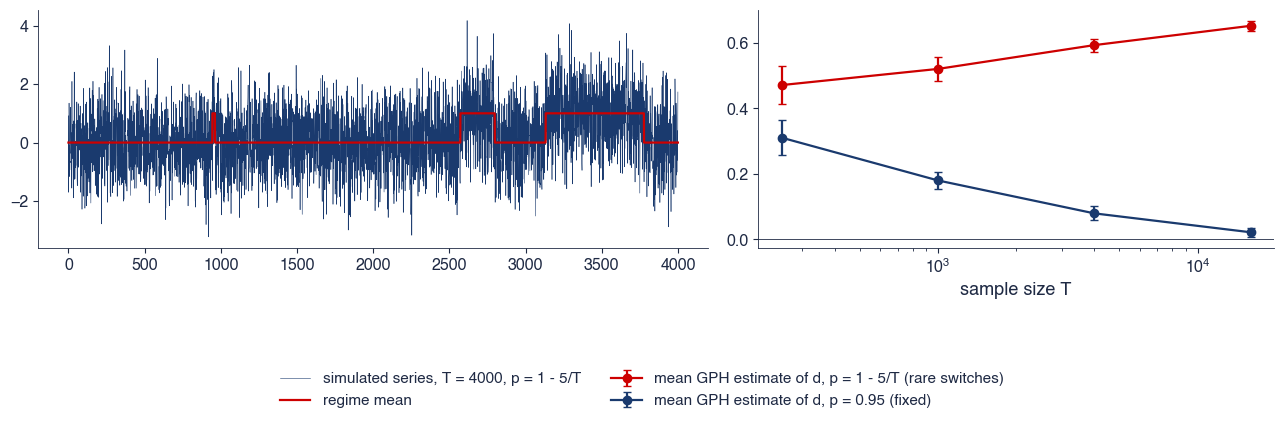

{'rare': [(0.47087582672658357, 0.028643128096298046), (0.5202165691758477, 0.018196304920396863), (0.5928544663930364, 0.00994290905931271), (0.651803113879277, 0.008007472965663426)], 'fixed': [(0.31015443968138556, 0.026737833606705574), (0.17959637667172856, 0.013404833019228256), (0.07908773925197207, 0.01074042560208149), (0.021415232680263643, 0.007101007051380634)], 'Ts': [250, 1000, 4000, 16000], 'c': 5.0, 'reps': 60, 'acf50': 0.1206642240680839, 'acf200': 0.06362827140491216, 'switches': 6}


In [16]:
def sim_ms(T, p, rng, mu=(0.0, 1.0), sigma=1.0):
    P = np.array([[p, 1 - p], [1 - p, p]])
    s = simulate_chain(P, T, rng)
    return np.asarray(mu)[s] + sigma * rng.normal(size=T), s


def fig_longmem(save_it=True, Ts=(250, 1000, 4000, 16000), reps=200, c=5.0):
    """Mean GPH estimate of d for y_t = mu_{S_t} + e_t: (a) p_ii = 1 - c / T, so the expected number of switches stays
    at c whatever T (Diebold and Inoue 2001); (b) fixed p_ii = 0.95 (short memory). Left: one path with T = 4000."""
    rng = np.random.default_rng(SEED)
    res = {'rare': [], 'fixed': []}
    for T in Ts:
        for k, p in (('rare', 1 - c / T), ('fixed', 0.95)):
            d = [gph(sim_ms(T, p, rng)[0]) for _ in range(reps)]
            res[k].append((float(np.mean(d)), float(np.std(d) / np.sqrt(reps))))
    y, s = sim_ms(4000, 1 - c / 4000, np.random.default_rng(SEED + 7))
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw=dict(width_ratios=[1.3, 1]))
    axs[0].plot(y, color=st.MainBlue, lw=0.4, label='simulated series, T = 4000, p = 1 - 5/T')
    axs[0].plot(np.array([0.0, 1.0])[s], color=st.IDAred, lw=1.6, label='regime mean')
    for k, cc, lab in (('rare', st.IDAred, 'p = 1 - 5/T (rare switches)'), ('fixed', st.MainBlue, 'p = 0.95 (fixed)')):
        m = np.array([v[0] for v in res[k]])
        se = np.array([v[1] for v in res[k]])
        axs[1].errorbar(Ts, m, yerr=2 * se, color=cc, marker='o', lw=1.6, capsize=3, label=f'mean GPH estimate of d, {lab}')
    axs[1].set_xscale('log')
    axs[1].axhline(0, color=st.DarkText, lw=0.6)
    axs[1].set_xlabel('sample size T')
    st.fig_legend_bottom(fig, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.13, 1, 1))
    save('ats_ch7_longmem', save_it)
    a = acf(y, 200)
    return dict(rare=res['rare'], fixed=res['fixed'], Ts=list(Ts), c=c, reps=reps, acf50=float(a[50]), acf200=float(a[200]),
                switches=int((np.diff(s) != 0).sum()))


print(fig_longmem(save_it=False, reps=60))

## 12. Romanian inflation regimes and change points

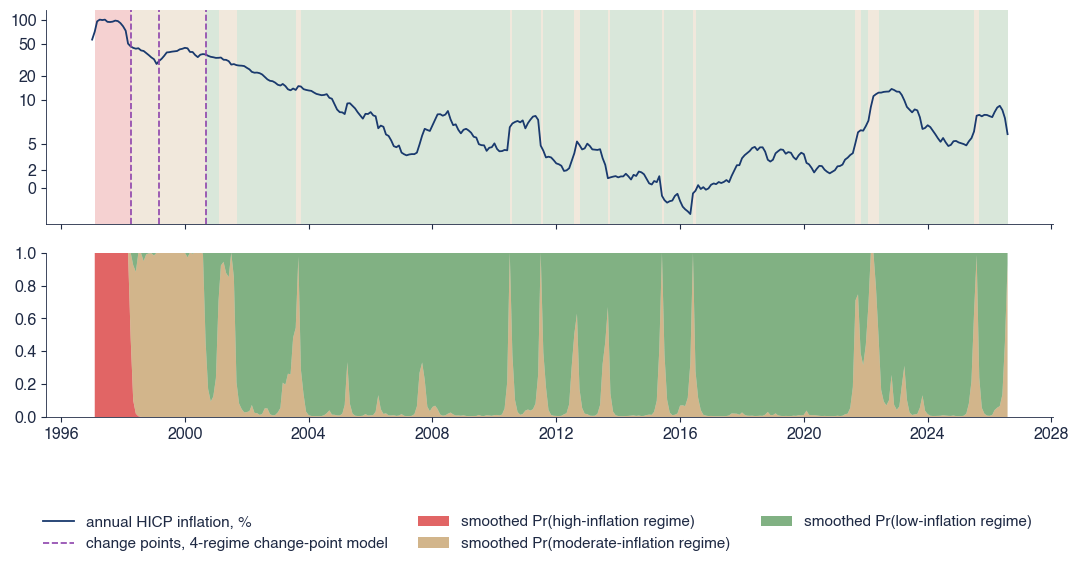

{'level': [68.70967841925454, 17.824606253376075, 2.854289340867787], 'sd': [10.5800647661715, 1.6997347005098227, 0.4498459389669305], 'dur': [14.612185800921852, 4.519694117582067, 18.633575586196148], 'ic': {'MS3': {'AIC': 883.8082415073962, 'BIC': 934.1457727705766, 'HQ': 903.8338406236877}, 'CP3': {'AIC': 852.1219507636658, 'BIC': 886.9710108689446, 'HQ': 865.9858270749445}, 'CP4': {'AIC': 851.0410891143838, 'BIC': 897.5065025880888, 'HQ': 869.5262575294221}, 'CP5': {'AIC': 849.4247169425923, 'BIC': 907.5064837847236, 'HQ': 872.5311774613901}}, 'breaks4': ['1998-04', '1999-03', '2000-09']}


In [17]:
def fig_ro_infl(save_it=True, starts=25):
    """Romanian annual HICP inflation: MSIH(3)-AR(1) (switching intercept and variance, common AR coefficient), against
    change-point models with 3 and 4 regimes (Chib 1998: P upper bidiagonal, no return)."""
    y = ro_inflation()
    ys, X = lag_design(y.values, 1)
    idx = y.index[1:]
    ms3 = best_em(ys, X, 3, starts=starts, switch=[True, False], seed=SEED, order=None)
    lev = ms3['beta'][:, 0] / (1 - ms3['beta'][0, 1])
    o = np.argsort(-lev)
    ms3 = dict(ms3, beta=ms3['beta'][o], sig2=ms3['sig2'][o], P=ms3['P'][np.ix_(o, o)], smooth=ms3['smooth'][:, o], filt=ms3['filt'][:, o])
    lev = ms3['beta'][:, 0] / (1 - ms3['beta'][0, 1])
    cps = {}
    for K in (3, 4, 5):
        mask = np.eye(K) + np.eye(K, k=1)
        best = None
        rng = np.random.default_rng(SEED)
        for s in range(starts):
            # starting values: K segments of equal length
            cut = np.sort(rng.choice(np.arange(12, len(ys) - 12), K - 1, replace=False))
            seg = np.searchsorted(cut, np.arange(len(ys)), side='right')
            W = np.eye(K)[seg]
            beta0 = np.vstack([np.linalg.lstsq(X * np.sqrt(W[:, [j]]), ys * np.sqrt(W[:, j]), rcond=None)[0] for j in range(K)])
            beta0[:, 1] = beta0[:, 1].mean()
            sig0 = np.array([max(np.var(ys[seg == j]) * 0.1, 0.05) for j in range(K)])
            r = em_msr(ys, X, K, switch=[True, False], P0=0.5 * mask + 0.5 * np.eye(K) * 0 + np.diag([0.0] * K),
                       beta0=beta0, sig20=sig0, P_mask=mask, xi1_fixed=np.eye(K)[0], maxit=2000)
            seg_r = r['smooth'].argmax(1)
            lens = np.bincount(seg_r, minlength=K)
            if lens.min() < 6:                       # every segment at least six months
                continue
            if best is None or r['loglik'] > best['loglik']:
                best = r
        cps[K] = best
    fig, axs = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True, gridspec_kw=dict(height_ratios=[1.3, 1]))
    cols = [st.IDAred, st.Amber, st.Forest]
    reg = ms3['smooth'].argmax(1)
    for j in range(3):
        shade(axs[0], pd.Series(reg == j, index=idx), color=cols[j], alpha=0.18)
    axs[0].plot(y.index, y.values, color=st.MainBlue, lw=1.3, label='annual HICP inflation, %')
    axs[0].set_yscale('symlog', linthresh=10)
    axs[0].set_yticks([0, 2, 5, 10, 20, 50, 100])
    axs[0].set_yticklabels(['0', '2', '5', '10', '20', '50', '100'])
    cp = cps[4]
    seg = cp['smooth'].argmax(1)
    brk = [idx[i] for i in range(1, len(seg)) if seg[i] != seg[i - 1]]
    for b in brk:
        axs[0].axvline(b, color=st.Purple, lw=1.2, ls='--')
    axs[0].plot([], [], color=st.Purple, lw=1.2, ls='--', label='change points, 4-regime change-point model')
    labs = ['high-inflation regime', 'moderate-inflation regime', 'low-inflation regime']
    axs[1].stackplot(idx, ms3['smooth'].T, colors=cols, alpha=0.6, labels=[f'smoothed Pr({l})' for l in labs])
    axs[1].set_ylim(0, 1)
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save('ats_ch7_ro_infl', save_it)
    T = len(ys)
    ic = {'MS3': info_criteria(ms3['loglik'], ms3['npar'], T)}
    for K, r in cps.items():
        ic[f'CP{K}'] = info_criteria(r['loglik'], r['npar'], T)
    # regime episodes of the MS model (most likely regime, runs of at least 3 months)
    eps = []
    cur = reg[0]
    st_ = idx[0]
    for i in range(1, len(reg)):
        if reg[i] != cur:
            eps.append(dict(regime=int(cur), start=str(st_)[:7], end=str(idx[i - 1])[:7]))
            cur, st_ = reg[i], idx[i]
    eps.append(dict(regime=int(cur), start=str(st_)[:7], end=str(idx[-1])[:7]))
    return dict(T=T, start=str(idx[0])[:7], end=str(idx[-1])[:7], last=float(y.iloc[-1]), max=float(y.max()),
                maxdate=str(y.idxmax())[:7], level=lev.tolist(), sd=np.sqrt(ms3['sig2']).tolist(), phi=float(ms3['beta'][0, 1]),
                P=np.diag(ms3['P']).tolist(), dur=(1 / (1 - np.diag(ms3['P']))).tolist(), loglik=float(ms3['loglik']),
                ll_cp={str(K): float(r['loglik']) for K, r in cps.items()}, ic={k: {kk: float(vv) for kk, vv in v.items()} for k, v in ic.items()},
                breaks4=[str(b)[:7] for b in brk], episodes=eps, P_full=ms3['P'].tolist(),
                last_probs=ms3['filt'][-1].tolist(), lastdate=str(idx[-1])[:7])


r = fig_ro_infl(save_it=False, starts=12)
print({k: r[k] for k in ('level', 'sd', 'dur', 'ic', 'breaks4')})

## 13. EUR/RON volatility regimes

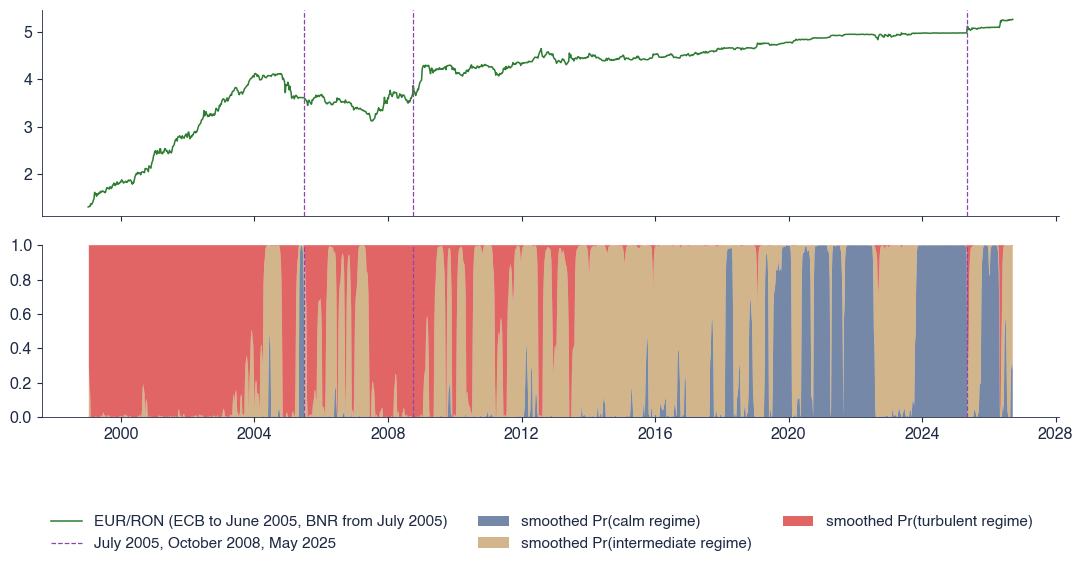

{'T': 1445, 'start': '1999-01-15', 'end': '2026-09-18', 'sd': [0.06718870028528334, 0.3886055531116839, 1.5084376281838363], 'mu': [0.005226642784975684, 0.01754587595681897, 0.254112596073504], 'P': [0.9359533155022803, 0.9393971777097035, 0.9510932356470111], 'dur': [15.613610725401474, 16.500881678576825, 20.447069300729268], 'share_turb_pre': 0.8724035608308606, 'share_turb_post': 0.17870036101083034, 'share_calm_pre': 0.02373887240356083, 'share_calm_post': 0.24729241877256317, 'p_turb_2008': 0.9999999999999991, 'p_turb_2025': 0.9999999883100306, 'big2025': '2025-05-09', 'big2025_val': 2.7583036209390954, 'lvl_2025_04': 4.977275, 'lvl_last': 5.2644, 'last_probs': [0.281394715575138, 0.7084037611116407, 0.010201523313221385], 'loglik': -1051.6988417325244}


In [18]:
def fig_eurron(save_it=True, starts=20):
    """Weekly log changes of EUR/RON (%): three regimes in mean and variance (MSIH(3)-AR(0)), ordered by volatility."""
    d = eurron_daily()
    w = d.resample('W-FRI').last().dropna()
    r = (100 * np.log(w).diff()).dropna().loc[:MARKET['end']]
    e = best_em(r.values, np.ones((len(r), 1)), 3, starts=starts, seed=SEED, order='var')
    fig, axs = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True, gridspec_kw=dict(height_ratios=[1.2, 1]))
    axs[0].plot(w.index, w.values, color=st.Forest, lw=1.1, label='EUR/RON (ECB to June 2005, BNR from July 2005)')
    for dte, lab in EVENTS_EURRON:
        for ax in axs:
            ax.axvline(pd.Timestamp(dte), color=st.Purple, lw=0.9, ls='--')
    axs[0].plot([], [], color=st.Purple, lw=0.9, ls='--', label='July 2005, October 2008, May 2025')
    cols = [st.MainBlue, st.Amber, st.IDAred]
    labs = ['calm', 'intermediate', 'turbulent']
    axs[1].stackplot(r.index, e['smooth'].T, colors=cols, alpha=0.6, labels=[f'smoothed Pr({l} regime)' for l in labs])
    axs[1].set_ylim(0, 1)
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    plt.tight_layout(rect=(0, 0.1, 1, 1))
    save('ats_ch7_eurron', save_it)
    sm_ = pd.DataFrame(e['smooth'], index=r.index)
    share = lambda a, b: (sm_.loc[a:b].values.argmax(1)).tolist()
    pre = np.array(share('1999-01-01', '2005-06-30'))
    post = np.array(share('2005-07-01', '2026-12-31'))
    biggest = r.loc['2025-01-01':].abs().idxmax()
    return dict(T=int(len(r)), start=str(r.index[0].date()), end=str(r.index[-1].date()), sd=np.sqrt(e['sig2']).tolist(),
                mu=e['beta'][:, 0].tolist(), P=np.diag(e['P']).tolist(), dur=(1 / (1 - np.diag(e['P']))).tolist(),
                share_turb_pre=float((pre == 2).mean()), share_turb_post=float((post == 2).mean()),
                share_calm_pre=float((pre == 0).mean()), share_calm_post=float((post == 0).mean()),
                p_turb_2008=float(sm_.loc['2008-10-01':'2009-03-31', 2].max()),
                p_turb_2025=float(sm_.loc['2025-04-15':'2025-06-30', 2].max()), big2025=str(biggest.date()),
                big2025_val=float(r.loc[biggest]), lvl_2025_04=float(w.loc['2025-04-01':'2025-04-30'].mean()),
                lvl_last=float(w.iloc[-1]), last_probs=e['filt'][-1].tolist(), loglik=float(e['loglik']))


print(fig_eurron(save_it=False, starts=10))

## 14. Forecasting: one-step density forecasts of US GDP growth

- Re-estimation every 8 quarters here.

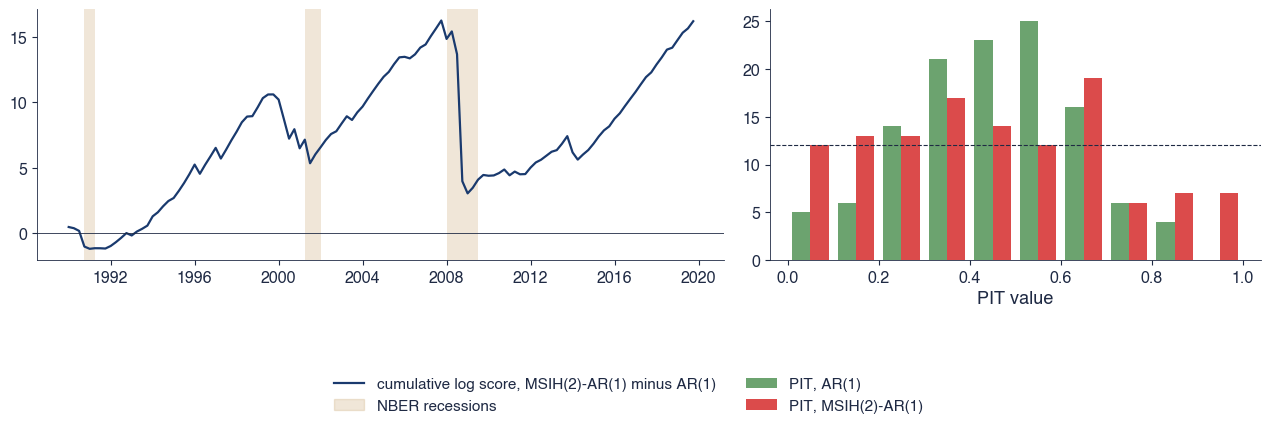

{'n': 120, 'rmse_ar': 0.5535658103546653, 'rmse_ms': 0.5596419656017537, 'ls_ar': -1.0280527940216944, 'ls_ms': -0.893192760600426, 'dm': 1.135847275198394, 'p_dm': 0.256020487672172, 'qps_lowmean': 1.485761883427817, 'qps_const': 0.16652777777777775, 'cum_pre08': 16.23698389603326, 'cum_post08': -0.05377988548104273, 'ks_ar': 6.743572397606233e-06, 'ks_ms': 0.013940908726192247}


In [19]:
def fig_forecast(save_it=True, first='1990-01-01', last='2019-10-01', refit=4):
    """Recursive one-step forecasts of US GDP growth, 1990Q1-2019Q4: Gaussian AR(1) against MSIH(2)-AR(1) (mixture
    density); RMSE, log score, PIT; Diebold-Mariano test on the log-score difference (Newey-West variance, 4 lags)."""
    y, rec = us_gdp()
    y = y.loc[US['start']:last]
    dates = y.loc[first:].index
    rows = []
    e = None
    for i, d in enumerate(dates):
        hist = y.loc[:d - pd.offsets.QuarterBegin(1)]
        ys, X = lag_design(hist.values, 1)
        lin = linear_ar(ys, X)
        if e is None or i % refit == 0:
            starts = [dict(P0=e['P'], beta0=e['beta'], sig20=e['sig2'])] if e is not None else []
            cand = [em_msr(ys, X, 2, switch=[True, False], maxit=500, **s0) for s0 in starts]
            cand.append(best_em(ys, X, 2, starts=3, switch=[True, False], seed=SEED + i, order=None, maxit=500))
            e = max(cand, key=lambda r: r['loglik'])
        f = hamilton_filter(msr_logf(ys, X, e['beta'], e['sig2']), e['P'])
        xi = f['filt'][-1] @ e['P']
        xn = np.array([1.0, hist.values[-1]])
        m = e['beta'] @ xn
        yt = float(y.loc[d])
        mean_ms = float(xi @ m)
        mu_l = float(lin['beta'] @ xn)
        rows.append(dict(date=d, y=yt, ar=mu_l, ms=mean_ms, ls_ar=float(stats.norm.logpdf(yt, mu_l, np.sqrt(lin['sig2']))),
                         ls_ms=mixture_logscore(yt, xi, m, e['sig2']), pit_ar=float(stats.norm.cdf(yt, mu_l, np.sqrt(lin['sig2']))),
                         pit_ms=mixture_pit(yt, xi, m, e['sig2']), p_lowvar=float(xi[np.argmax(e['sig2'])]),
                         p_lowmean=float(xi[np.argmin(e['beta'][:, 0] / (1 - e['beta'][0, 1]))])))
    D = pd.DataFrame(rows).set_index('date')
    dls = D['ls_ms'] - D['ls_ar']
    n = len(dls)
    u = dls - dls.mean()
    lr = u @ u / n + 2 * sum((1 - k / 5) * (u[k:].values @ u[:-k].values) / n for k in range(1, 5))
    dm = float(dls.mean() / np.sqrt(lr / n))
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw=dict(width_ratios=[1.4, 1]))
    shade(axs[0], rec.reindex(D.index))
    axs[0].plot(D.index, dls.cumsum(), color=st.MainBlue, lw=1.6, label='cumulative log score, MSIH(2)-AR(1) minus AR(1)')
    axs[0].axhline(0, color=st.DarkText, lw=0.6)
    bins = np.linspace(0, 1, 11)
    axs[1].hist([D['pit_ar'], D['pit_ms']], bins=bins, color=[st.Forest, st.IDAred], alpha=0.7, label=['PIT, AR(1)', 'PIT, MSIH(2)-AR(1)'])
    axs[1].axhline(n / 10, color=st.DarkText, lw=0.8, ls='--')
    axs[1].set_xlabel('PIT value')
    h0, l0 = axs[0].get_legend_handles_labels()
    h1, l1 = axs[1].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h0 + [patch(st.Amber)] + h1, l0 + ['NBER recessions'] + l1, ncol=2, y=0.02)
    plt.tight_layout(rect=(0, 0.12, 1, 1))
    save('ats_ch7_forecast', save_it)
    rr = rec.reindex(D.index).values
    pre08 = D.index < pd.Timestamp('2008-01-01')
    return dict(n=int(n), rmse_ar=float(np.sqrt(((D['y'] - D['ar']) ** 2).mean())), rmse_ms=float(np.sqrt(((D['y'] - D['ms']) ** 2).mean())),
                ls_ar=float(D['ls_ar'].mean()), ls_ms=float(D['ls_ms'].mean()), dm=dm, p_dm=float(2 * stats.norm.sf(abs(dm))),
                qps_lowmean=qps(D['p_lowmean'].values, rr), qps_const=qps(np.full(n, rr.mean()), rr),
                cum_pre08=float(dls[pre08].sum()), cum_post08=float(dls[~pre08].sum()),
                ks_ar=float(stats.kstest(D['pit_ar'], 'uniform').pvalue), ks_ms=float(stats.kstest(D['pit_ms'], 'uniform').pvalue))


print(fig_forecast(save_it=False, refit=8))

## 15. AI mini-case: how robust is a recession dating?

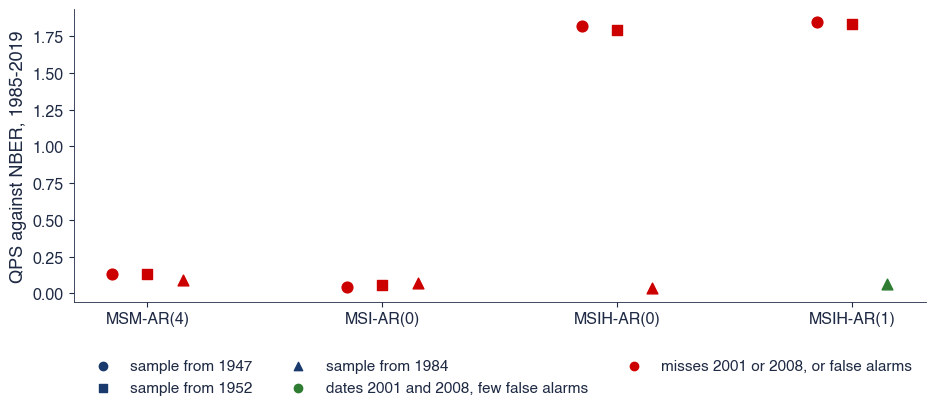

0.03384704304110875 1.8459658965061851 1


In [20]:
def dating_variant(y, model, start):
    """Smoothed probability of the low-mean regime for one specification (estimated from `start` to 2019Q4)."""
    ye = y.loc[start:US['est_end']]
    if model == 'MSM-AR(4)':
        r = fit_hamilton(ye, nrand=6)
        return pd.Series(r['smooth'][:, 0], index=ye.index[4:])
    p = 1 if model.endswith('AR(1)') else 0
    ys, X = lag_design(ye.values, p)
    sv = model.startswith('MSIH')
    e = best_em(ys, X, 2, starts=10, switch=[True] + [False] * p, switch_var=sv, seed=SEED, order=None)
    lev = e['beta'][:, 0] / (1 - (e['beta'][0, 1] if p else 0))
    lo = int(np.argmin(lev))
    return pd.Series(e['smooth'][:, lo], index=ye.index[p:])


def fig_ai_case(save_it=True, window=('1985-01-01', US['est_end'])):
    y, rec = us_gdp()
    models = ['MSM-AR(4)', 'MSI-AR(0)', 'MSIH-AR(0)', 'MSIH-AR(1)']
    starts = ['1947-04-01', '1952-04-01', '1984-01-01']
    rows = []
    for m in models:
        for s in starts:
            p = dating_variant(y, m, s).loc[window[0]:window[1]]
            rr = rec.reindex(p.index).values
            false = float((p.values[rr == 0] > 0.5).mean())           # share of non-recession quarters signalled
            rows.append(dict(model=m, start=s[:4], qps=qps(p.values, rr), conc=concordance(p.values > 0.5, rr),
                             d2001=bool(p.loc['2001-01-01':'2001-10-01'].max() > 0.5 and false < 0.2),
                             d2008=bool(p.loc['2008-01-01':'2009-04-01'].max() > 0.5 and false < 0.2),
                             false=false, share=float((p > 0.5).mean())))
    t = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(11, 3.8))
    mk = {'1947': 'o', '1952': 's', '1984': '^'}
    cl = {True: st.Forest, False: st.IDAred}
    for i, m in enumerate(models):
        for _, r in t[t['model'] == m].iterrows():
            ax.scatter(i + {'1947': -0.15, '1952': 0, '1984': 0.15}[r['start']], r['qps'], marker=mk[r['start']], s=60,
                       color=cl[r['d2008'] and r['d2001']], zorder=3)
    for s, m_ in mk.items():
        ax.scatter([], [], marker=m_, color=st.MainBlue, label=f'sample from {s}')
    ax.scatter([], [], marker='o', color=st.Forest, label='dates 2001 and 2008, few false alarms')
    ax.scatter([], [], marker='o', color=st.IDAred, label='misses 2001 or 2008, or false alarms')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models)
    ax.set_ylabel('QPS against NBER, 1985-2019')
    st.legend_outside_bottom(ax, ncol=3, y=-0.15)
    save('ats_ch7_ai_case', save_it)
    return dict(rows=rows, qmin=float(t['qps'].min()), qmax=float(t['qps'].max()), n=int(len(t)),
                n_both=int((t['d2001'] & t['d2008']).sum()), n_false=int((t['false'] >= 0.2).sum()), n2008=int(t['d2008'].sum()), n2001=int(t['d2001'].sum()),
                qconst=qps(np.full(len(rec.loc[window[0]:window[1]]), rec.loc[window[0]:window[1]].mean()), rec.loc[window[0]:window[1]].values))


r = fig_ai_case(save_it=False)
print(r['qmin'], r['qmax'], r['n_both'])

## Exercises

1. Add a third regime to Hamilton's model on today's GDP: does it separate recessions from the Great Moderation?
2. Replace the leading indicator of Filardo by the term spread (FRED T10Y3M) on post-1982 data.
3. Run the Gibbs sampler with the variance ordering instead of the mean ordering and compare the posteriors.